In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import sklearn as sk
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.fftpack import fft
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

## Data preprocessing 

In [4]:
def load_and_transpose_csv(filename):
    # Load the CSV into a dataframe
    df = pd.read_csv(filename)

    # Rename the 'Name' column to 'dates'
    df = df.rename(columns={"Name": "Date"})

    # Transpose the dataframe
    df = df.transpose()

    # convert the index to datetime
    df.index = pd.to_datetime(df.index, format="%Y-%m-%d")

    # Set the first row as the column names
    df.columns = df.iloc[0]

    # Drop the first row since it's now the column names
    df = df[1:]

    # df["date"] = pd.to_datetime(df["date"])

    return df

In [7]:
data = pd.read_csv("../data/raw/COVID-19 hospital activities/MV beds-confirmed COVID-19 patients.csv")
data.head()

,Regions,01-Aug-20,02-Aug-20,03-Aug-20,04-Aug-20,05-Aug-20,06-Aug-20,07-Aug-20,08-Aug-20,09-Aug-20,...,22-Aug-22,23-Aug-22,24-Aug-22,25-Aug-22,26-Aug-22,27-Aug-22,28-Aug-22,29-Aug-22,30-Aug-22,31-Aug-22
0,ENGLAND,74,72,67,65,63,61,57,55,56,...,162,135,150,141,135,135,138,144,141,144
1,East of England,9,9,8,8,8,9,9,11,9,...,20,14,14,5,6,9,11,10,9,4
2,London,16,15,17,15,13,11,10,10,12,...,80,52,67,72,69,66,62,65,65,62
3,Midlands,13,10,10,13,13,14,10,5,6,...,17,20,21,24,22,21,20,20,16,19
4,North East and Yorkshire,9,8,7,7,7,6,7,8,7,...,17,20,18,15,14,16,17,15,17,20


In [14]:
# Rename the 'Regions' column to 'Date'
data = data.rename(columns={"Regions": "Date"})
data_transposed = data.set_index("Date").transpose()

# Converting the index to datetime
data_transposed.index = pd.to_datetime(data_transposed.index, format="%d-%b-%y")

# Convert all columns to numeric, handling commas in numbers
for col in data_transposed.columns:
    data_transposed[col] = pd.to_numeric(data_transposed[col].astype(str).str.replace(',', ''), errors='coerce')

data_transposed.head()

Date,ENGLAND,East of England,London,Midlands,North East and Yorkshire,North West,South East,South West
2020-08-01,74,9,16,13,9,15,12,0
2020-08-02,72,9,15,10,8,15,15,0
2020-08-03,67,8,17,10,7,13,12,0
2020-08-04,65,8,15,13,7,13,9,0
2020-08-05,63,8,13,13,7,13,9,0


## EDA and Trend analysis

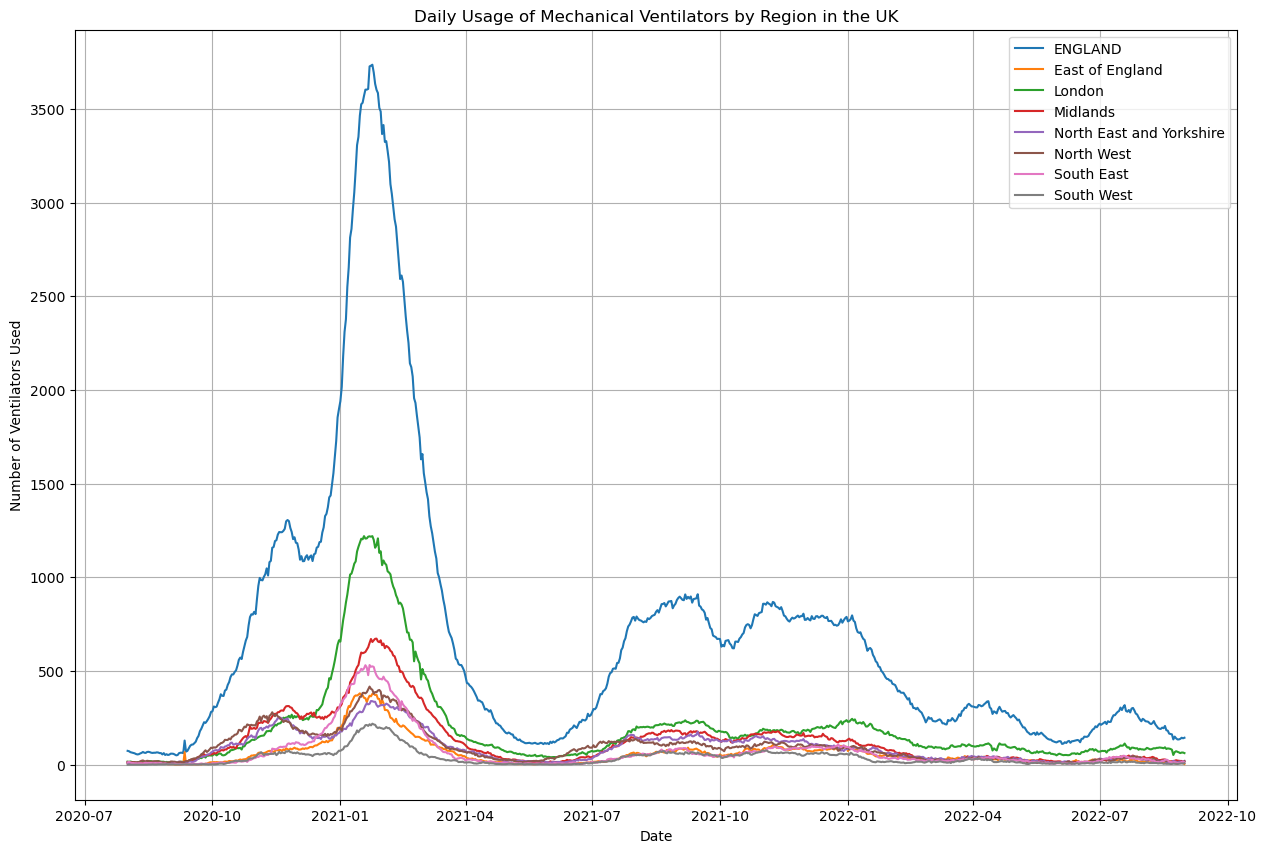

In [15]:
# Plotting the time series for all regions
plt.figure(figsize=(15, 10))
for column in data_transposed.columns:
    plt.plot(data_transposed.index, data_transposed[column], label=column)

plt.title("Daily Usage of Mechanical Ventilators by Region in the UK")
plt.xlabel("Date")
plt.ylabel("Number of Ventilators Used")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Calculating summary statistics for each region
summary_statistics = data_transposed.describe().transpose()

# Displaying the summary statistics
summary_statistics

,count,mean,std,min,25%,50%,75%,max
Date,,,,,,,,
ENGLAND,761.0,681.642576,748.928922,50.0,213.0,426.0,809.0,3736.0
East of England,761.0,61.085414,73.588252,1.0,15.0,36.0,80.0,381.0
London,761.0,197.724047,243.489809,10.0,72.0,117.0,207.0,1220.0
Midlands,761.0,127.886991,141.408127,5.0,28.0,79.0,167.0,673.0
North East and Yorkshire,761.0,91.621551,79.291144,4.0,24.0,72.0,137.0,340.0
North West,761.0,95.362681,88.114682,8.0,27.0,82.0,120.0,417.0
South East,761.0,71.296978,105.858588,2.0,13.0,34.0,82.0,532.0
South West,761.0,36.664915,42.367371,0.0,7.0,18.0,57.0,219.0


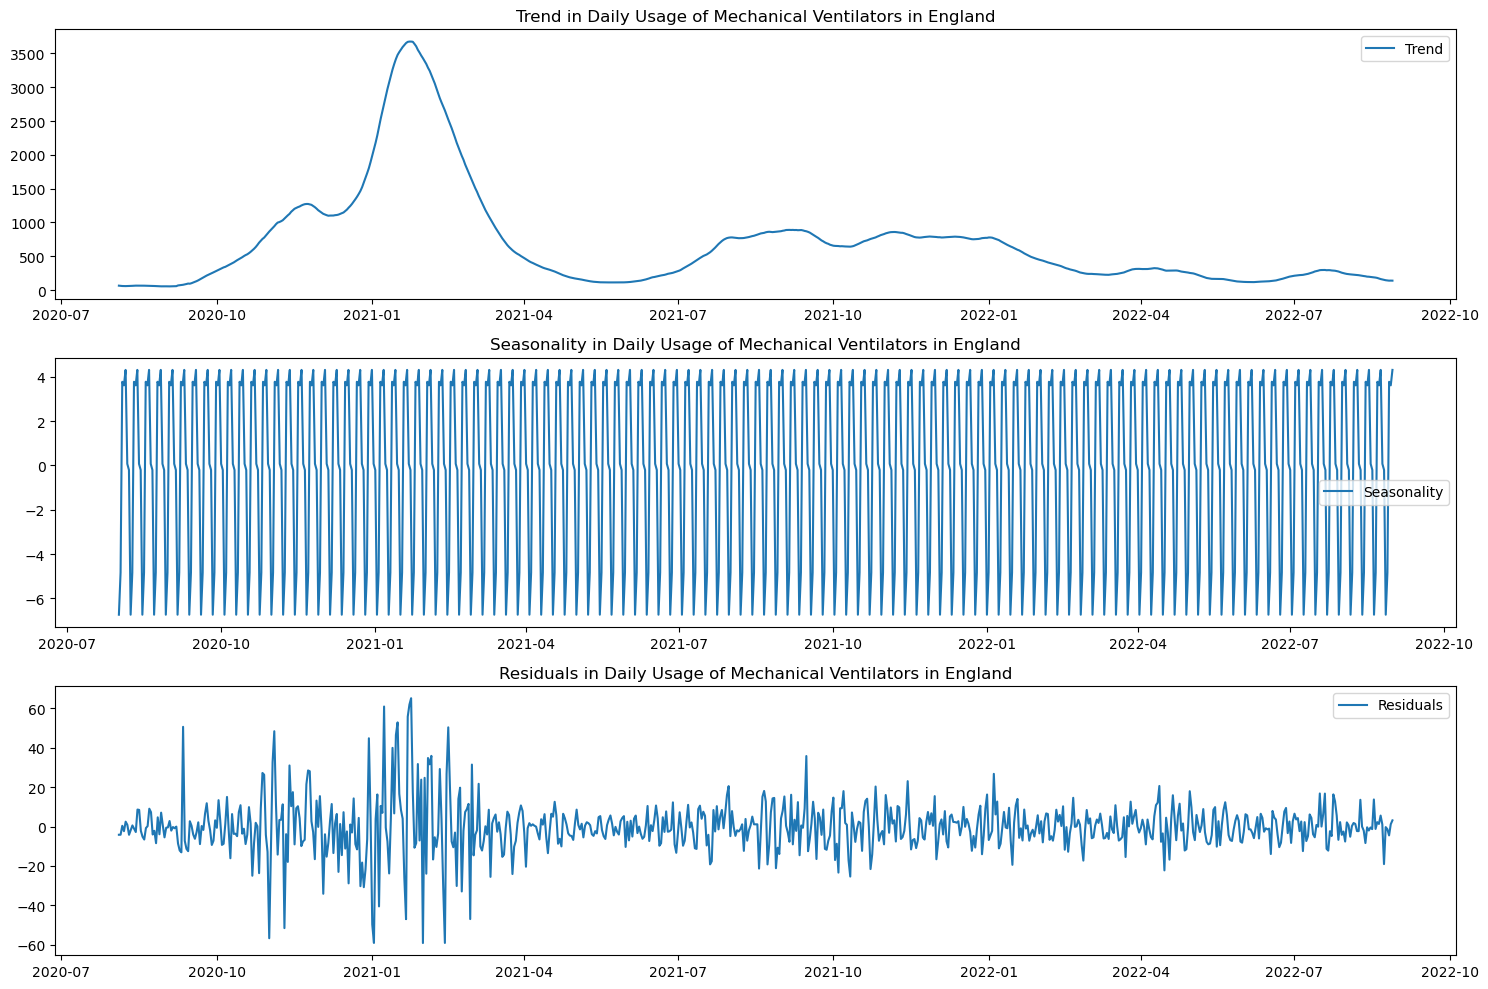

In [22]:
# Decomposing the time series for England to analyze trend and seasonality
england_series = data_transposed["ENGLAND"]
england_decomposition = seasonal_decompose(england_series, model="additive")

# Plotting the trend, seasonality, and residuals for England
plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.plot(england_decomposition.trend, label="Trend")
plt.title("Trend in Daily Usage of Mechanical Ventilators in England")
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(england_decomposition.seasonal, label="Seasonality")
plt.title("Seasonality in Daily Usage of Mechanical Ventilators in England")
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(england_decomposition.resid, label="Residuals")
plt.title("Residuals in Daily Usage of Mechanical Ventilators in England")
plt.legend()
plt.tight_layout()
plt.show()

1. Trend Component: The trend component appears to be relatively flat, indicating that the differencing operation has successfully removed any underlying trend.
2. Seasonal Component: The seasonal component shows a repeating pattern, suggesting the presence of weekly seasonality in the data.
3. Residual Component: The residual component represents the remaining noise after extracting the trend and seasonal components.

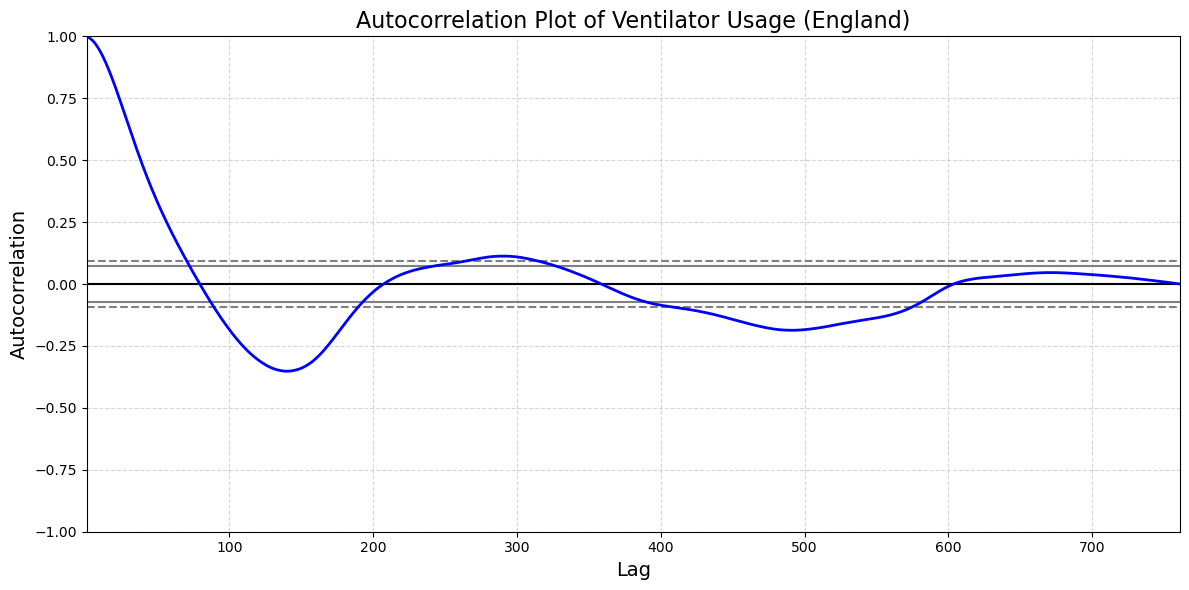

In [24]:
plt.figure(figsize=(12, 6))
autocorrelation_plot(england_series, linewidth=2, color="blue")
plt.title("Autocorrelation Plot of Ventilator Usage (England)", fontsize=16)
plt.xlabel("Lag", fontsize=14)
plt.ylabel("Autocorrelation", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('../report/figures/autocorrelationplot.png')
plt.show()

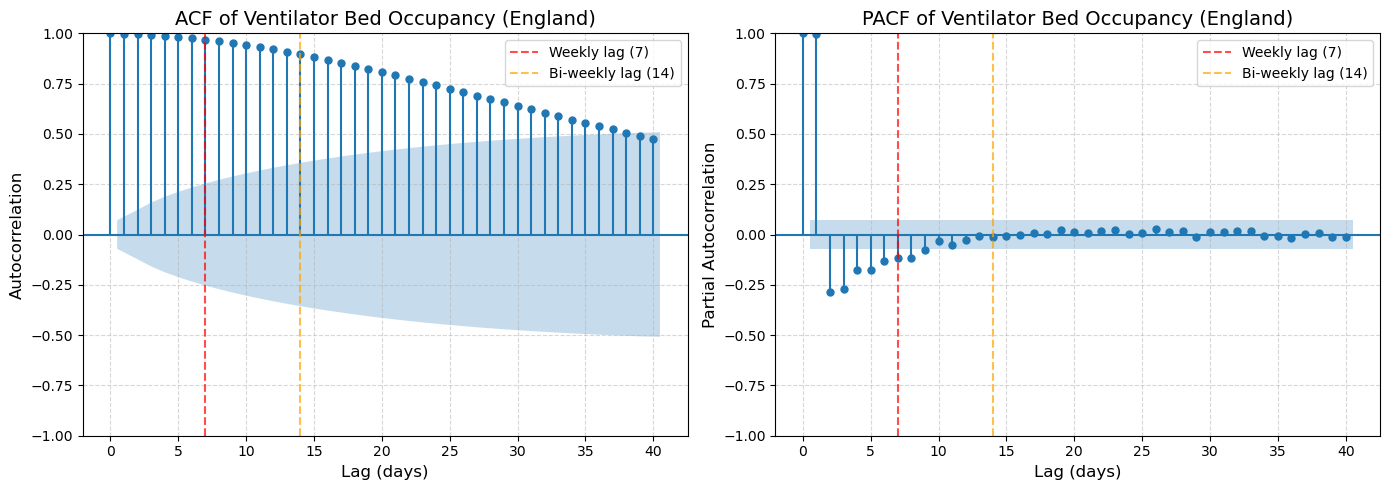

In [23]:
# Autocorrelation function (ACF) and partial autocorrelation function (PACF) plots
# for mechanical ventilator bed occupancy, showing significant correlations at weekly lags (7 and 14 days)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF Plot
plot_acf(england_series, lags=40, ax=axes[0])
axes[0].set_title("ACF of Ventilator Bed Occupancy (England)", fontsize=14)
axes[0].set_xlabel("Lag (days)", fontsize=12)
axes[0].set_ylabel("Autocorrelation", fontsize=12)
axes[0].axvline(x=7, color='red', linestyle='--', alpha=0.7, label='Weekly lag (7)')
axes[0].axvline(x=14, color='orange', linestyle='--', alpha=0.7, label='Bi-weekly lag (14)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle="--", alpha=0.5)

# PACF Plot
plot_pacf(england_series, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Ventilator Bed Occupancy (England)", fontsize=14)
axes[1].set_xlabel("Lag (days)", fontsize=12)
axes[1].set_ylabel("Partial Autocorrelation", fontsize=12)
axes[1].axvline(x=7, color='red', linestyle='--', alpha=0.7, label='Weekly lag (7)')
axes[1].axvline(x=14, color='orange', linestyle='--', alpha=0.7, label='Bi-weekly lag (14)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('../report/figures/acf_pacf.png')
plt.show()

In [19]:
# Splitting the data into training and testing sets based on the specified dates
training_data = england_series.loc["2020-01-01":"2021-12-31"]
testing_data = england_series.loc["2022-01-01":"2022-02-28"]

# Displaying the training data
training_data.head()

Date,ENGLAND,East of England,London,Midlands,North East and Yorkshire,North West,South East,South West
2020-08-01,74,9,16,13,9,15,12,0
2020-08-02,72,9,15,10,8,15,15,0
2020-08-03,67,8,17,10,7,13,12,0
2020-08-04,65,8,15,13,7,13,9,0
2020-08-05,63,8,13,13,7,13,9,0


In [21]:
testing_data.head()

Date,ENGLAND,East of England,London,Midlands,North East and Yorkshire,North West,South East,South West
2022-01-01,765,73,229,135,84,95,94,55
2022-01-02,769,86,230,139,87,81,93,53
2022-01-03,777,83,238,129,83,95,85,64
2022-01-04,797,90,245,134,87,98,84,59
2022-01-05,769,82,236,125,93,100,80,53


In [48]:
# Function to fit and forecast using ARIMA for a given series
def fit_forecast_arima(train_series, test_series):
    # Finding the best ARIMA model using AIC criterion
    best_aic = float("inf")
    best_order = None
    for p in range(5):
        for d in range(2):
            for q in range(5):
                try:
                    model = ARIMA(train_series, order=(p, d, q))
                    fit_model = model.fit()
                    if fit_model.aic < best_aic:
                        best_aic = fit_model.aic
                        best_order = (p, d, q)
                except:
                    continue

    # Fitting the best ARIMA model
    best_model = ARIMA(train_series, order=best_order)
    fit_best_model = best_model.fit()

    # Forecasting for the testing period
    forecast = fit_best_model.predict(
        start=test_series.index[0], end=test_series.index[-1]
    )

    # Evaluating the forecast
    mae = mean_absolute_error(test_series, forecast)
    mse = mean_squared_error(test_series, forecast)
    rmse = np.sqrt(mse)

    return forecast, mae, mse, rmse


# Applying ARIMA to the "ENGLAND" series and getting the forecast and evaluation metrics
england_forecast, england_mae, england_mse, england_rmse = fit_forecast_arima(
    training_data["ENGLAND"], testing_data["ENGLAND"]
)

# Displaying the results for "ENGLAND"
england_forecast.head(), england_mae, england_mse, england_rmse

/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/statsmodels/tsa/base/t

(2022-01-01    800.195759
 2022-01-02    812.182942
 2022-01-03    825.788367
 2022-01-04    839.712071
 2022-01-05    853.712056
 Freq: D, Name: predicted_mean, dtype: float64,
 539.8619766694281,
 358461.1283510246,
 598.7162335790008)

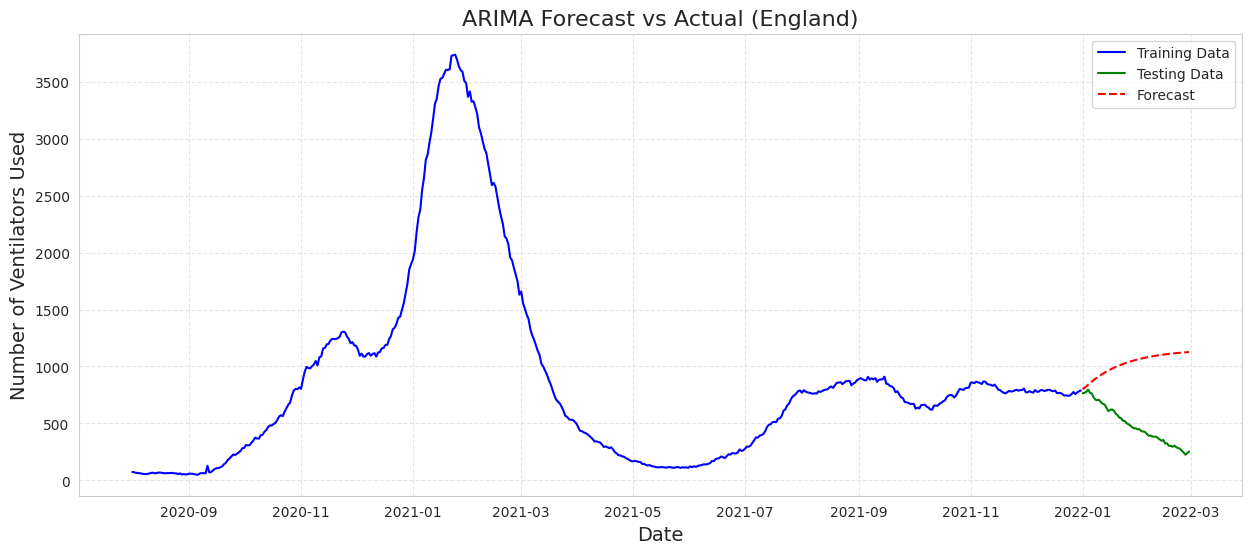

In [49]:
# Function to visualize the forecast along with training and testing data
def plot_forecast(train_series, test_series, forecast, title="Forecast vs Actual"):
    plt.figure(figsize=(15, 6))
    plt.plot(
        train_series.index, train_series.values, label="Training Data", color="blue"
    )
    plt.plot(test_series.index, test_series.values, label="Testing Data", color="green")
    plt.plot(
        test_series.index,
        forecast.values,
        label="Forecast",
        color="red",
        linestyle="--",
    )
    plt.title(title, fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Number of Ventilators Used", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


# Plotting the ARIMA forecast for "ENGLAND" series
plot_forecast(
    training_data["ENGLAND"],
    testing_data["ENGLAND"],
    england_forecast,
    title="ARIMA Forecast vs Actual (England)",
)

In [50]:
# Function to save the experiment's metrics to a DataFrame
def save_metrics_to_dataframe(model_name, test_series, forecast, metrics_df=None):
    # Calculating evaluation metrics
    mae = mean_absolute_error(test_series, forecast)
    mse = mean_squared_error(test_series, forecast)
    rmse = np.sqrt(mse)
    forecast_bias = (forecast - test_series).mean()  # Forecast bias

    # Creating a DataFrame to hold the metrics
    metrics_data = {
        "Model": [model_name],
        "MAE": [mae],
        "MSE": [mse],
        "RMSE": [rmse],
        "Forecast Bias": [forecast_bias],
    }
    new_metrics_df = pd.DataFrame(metrics_data)

    # Appending to the existing metrics DataFrame if provided
    if metrics_df is not None:
        metrics_df = pd.concat([metrics_df, new_metrics_df], ignore_index=True)
    else:
        metrics_df = new_metrics_df

    return metrics_df


# Initializing an empty DataFrame to hold the metrics
metrics_df = pd.DataFrame()

# Saving the metrics for the ARIMA model (ENGLAND) to the DataFrame
metrics_df = save_metrics_to_dataframe(
    "ARIMA (ENGLAND)", testing_data["ENGLAND"], england_forecast, metrics_df
)

# Displaying the metrics DataFrame
metrics_df

,Model,MAE,MSE,RMSE,Forecast Bias
0,ARIMA (ENGLAND),539.861977,358461.128351,598.716234,539.861977


## feature Engineering

 - Time Delay Embedding
 - fourier terms
 - temporal features
 - Exponentially Weighted Moving Averages (EWMA)

In [51]:
# Function to create time delay embedding features (lagged versions of the series)
def create_time_delay_embedding(series, max_lag):
    lagged_data = pd.DataFrame({"Original": series})
    for lag in range(1, max_lag + 1):
        lagged_data[f"Lag_{lag}"] = series.shift(lag)
    return lagged_data.dropna()


# Applying time delay embedding to the "ENGLAND" series with a maximum lag of 5
max_lag = 5
england_time_delay_embedding = create_time_delay_embedding(
    data_transposed["ENGLAND"], max_lag
)

# Displaying the first few rows of the time delay embedding features
england_time_delay_embedding.head()

,Original,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
2020-08-06,61,63.0,65.0,67.0,72.0,74.0
2020-08-07,57,61.0,63.0,65.0,67.0,72.0
2020-08-08,55,57.0,61.0,63.0,65.0,67.0
2020-08-09,56,55.0,57.0,61.0,63.0,65.0
2020-08-10,60,56.0,55.0,57.0,61.0,63.0


In [5]:
# Function to create Fourier terms for seasonality representation
def create_fourier_terms(series, frequency, k_terms):
    fourier_data = pd.DataFrame({"Original": series})
    N = len(series)
    t = np.arange(0, N)
    for k in range(1, k_terms + 1):
        fourier_data[f"Cos_{k}"] = np.cos(2 * np.pi * k * t / frequency)
        fourier_data[f"Sin_{k}"] = np.sin(2 * np.pi * k * t / frequency)
    return fourier_data


# Frequency represents the seasonal period (e.g., 365 for annual seasonality, 7 for weekly)
frequency = 7  # Weekly seasonality
k_terms = 3  # Number of Fourier terms

# Applying Fourier terms to the "ENGLAND" series
england_fourier_terms = create_fourier_terms(
    data_transposed["ENGLAND"], frequency, k_terms
)

# Displaying the first few rows of the Fourier terms
england_fourier_terms.head()

NameError: name 'data_transposed' is not defined

In [53]:
# Function to extract temporal features such as day of the week, month, quarter, etc.
def create_temporal_features(series):
    temporal_data = pd.DataFrame({"Original": series})
    temporal_data["Day_of_Week"] = series.index.dayofweek
    temporal_data["Month"] = series.index.month
    temporal_data["Quarter"] = series.index.quarter
    temporal_data["Day_of_Year"] = series.index.dayofyear
    temporal_data["Week_of_Year"] = series.index.weekofyear
    return temporal_data


# Applying temporal features to the "ENGLAND" series
england_temporal_features = create_temporal_features(data_transposed["ENGLAND"])

# Displaying the first few rows of the temporal features
england_temporal_features.head()

/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  temporal_data['Week_of_Year'] = series.index.weekofyear


,Original,Day_of_Week,Month,Quarter,Day_of_Year,Week_of_Year
2020-08-01,74,5,8,3,214,31
2020-08-02,72,6,8,3,215,31
2020-08-03,67,0,8,3,216,32
2020-08-04,65,1,8,3,217,32
2020-08-05,63,2,8,3,218,32


In [54]:
# Function to compute Exponentially Weighted Moving Averages (EWMA)
def create_ewma_features(series, span_values):
    ewma_data = pd.DataFrame({"Original": series})
    for span in span_values:
        ewma_data[f"EWMA_{span}"] = series.ewm(span=span).mean()
    return ewma_data


# Span values control the decay of the weights; larger values result in smoother curves
span_values = [3, 7, 14]

# Applying EWMA to the "ENGLAND" series with different span values
england_ewma_features = create_ewma_features(data_transposed["ENGLAND"], span_values)

# Displaying the first few rows of the EWMA features
england_ewma_features.head()

,Original,EWMA_3,EWMA_7,EWMA_14
2020-08-01,74,74.000000,74.000000,74.000000
2020-08-02,72,72.666667,72.857143,72.928571
2020-08-03,67,69.428571,70.324324,70.663837
2020-08-04,65,67.066667,68.377143,68.931109
2020-08-05,63,64.967742,66.614597,67.383692


In [56]:
# Combining all the engineered features into a single DataFrame
england_combined_features = pd.concat(
    [
        england_time_delay_embedding,
        england_fourier_terms.drop(columns="Original"),
        england_temporal_features.drop(columns="Original"),
        england_ewma_features.drop(columns="Original"),
    ],
    axis=1,
)

# Splitting the combined features into training and testing sets based on the specified dates
training_features = england_combined_features.loc["2020-01-01":"2021-12-31"]
testing_features = england_combined_features.loc["2022-01-01":"2022-02-28"]

# Displaying the first few rows of the training features
training_features.head()

,Original,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Cos_1,Sin_1,Cos_2,Sin_2,Cos_3,Sin_3,Day_of_Week,Month,Quarter,Day_of_Year,Week_of_Year,EWMA_3,EWMA_7,EWMA_14
2020-08-01,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,5,8,3,214,31,74.000000,74.000000,74.000000
2020-08-02,NaN,NaN,NaN,NaN,NaN,NaN,0.623490,0.781831,-0.222521,0.974928,-0.900969,0.433884,6,8,3,215,31,72.666667,72.857143,72.928571
2020-08-03,NaN,NaN,NaN,NaN,NaN,NaN,-0.222521,0.974928,-0.900969,-0.433884,0.623490,-0.781831,0,8,3,216,32,69.428571,70.324324,70.663837
2020-08-04,NaN,NaN,NaN,NaN,NaN,NaN,-0.900969,0.433884,0.623490,-0.781831,-0.222521,0.974928,1,8,3,217,32,67.066667,68.377143,68.931109
2020-08-05,NaN,NaN,NaN,NaN,NaN,NaN,-0.900969,-0.433884,0.623490,0.781831,-0.222521,-0.974928,2,8,3,218,32,64.967742,66.614597,67.383692


In [57]:
# Removing rows with NaN values from the training and testing features
training_features = training_features.dropna()
testing_features = testing_features.dropna()

# Displaying the first few rows of the cleaned training features
training_features.head()

,Original,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Cos_1,Sin_1,Cos_2,Sin_2,Cos_3,Sin_3,Day_of_Week,Month,Quarter,Day_of_Year,Week_of_Year,EWMA_3,EWMA_7,EWMA_14
2020-08-06,61.0,63.0,65.0,67.0,72.0,74.0,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,3,8,3,219,32,62.952381,64.907039,65.906620
2020-08-07,57.0,61.0,63.0,65.0,67.0,72.0,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,4,8,3,220,32,59.952756,62.625766,64.029806
2020-08-08,55.0,57.0,61.0,63.0,65.0,67.0,1.000000,-2.449294e-16,1.000000,-4.898587e-16,1.000000,-7.347881e-16,5,8,3,221,32,57.466667,60.507232,62.263709
2020-08-09,56.0,55.0,57.0,61.0,63.0,65.0,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,6,8,3,222,32,56.731898,59.288950,61.110414
2020-08-10,60.0,56.0,55.0,57.0,61.0,63.0,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,0,8,3,223,33,58.367546,59.477320,60.915844


In [58]:
# Defining the X and y variables for training and testing
X_train = training_features.drop(columns="Original")
y_train = training_features["Original"]
X_test = testing_features.drop(columns="Original")
y_test = testing_features["Original"]


# Function to train and evaluate a regression model
def train_evaluate_model(
    model, X_train, y_train, X_test, y_test, model_name, metrics_df=None
):
    # Training the model
    model.fit(X_train, y_train)

    # Forecasting for the testing period
    forecast = model.predict(X_test)

    # Adding the forecast to the DataFrame for comparison
    metrics_df = save_metrics_to_dataframe(model_name, y_test, forecast, metrics_df)

    return metrics_df


# Training and evaluating Linear Regression
linear_reg_model = LinearRegression()
metrics_df = train_evaluate_model(
    linear_reg_model, X_train, y_train, X_test, y_test, "Linear Regression", metrics_df
)

# Displaying the updated metrics DataFrame
metrics_df

,Model,MAE,MSE,RMSE,Forecast Bias
0,ARIMA (ENGLAND),539.861977,358461.128351,598.716234,539.861977
1,Linear Regression,0.126995,0.025989,0.161212,-0.062473


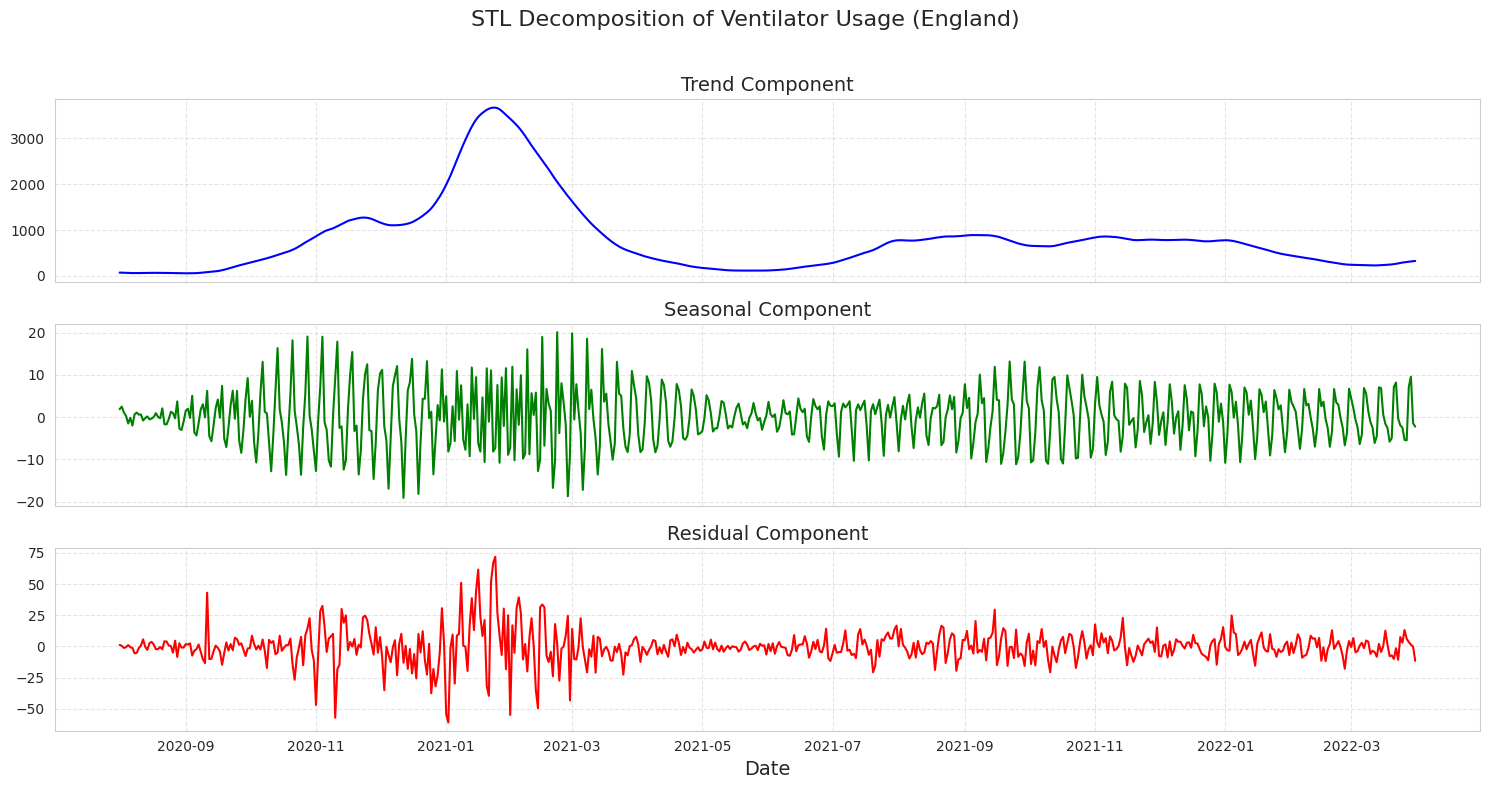

In [15]:
# Applying STL decomposition with LOESS to the ventilator usage data
stl = STL(england_series, seasonal=13)
result_stl = stl.fit()

trend = result_stl.trend
seasonal = result_stl.seasonal
residual = result_stl.resid

# Plotting the enhanced STL decomposition
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
axes[0].plot(trend, color="blue")
axes[0].set_title("Trend Component", fontsize=14)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(seasonal, color="green")
axes[1].set_title("Seasonal Component", fontsize=14)
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].plot(residual, color="red")
axes[2].set_title("Residual Component", fontsize=14)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("STL Decomposition of Ventilator Usage (England)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjusting layout to fit the title
plt.show()

In [59]:
# Training and evaluating Ridge Regression
ridge_reg_model = Ridge()
metrics_df = train_evaluate_model(
    ridge_reg_model, X_train, y_train, X_test, y_test, "Ridge Regression", metrics_df
)

# Training and evaluating Lasso Regression
lasso_reg_model = Lasso()
metrics_df = train_evaluate_model(
    lasso_reg_model, X_train, y_train, X_test, y_test, "Lasso Regression", metrics_df
)

# Training and evaluating Support Vector Regression (SVR)
svr_model = SVR()
metrics_df = train_evaluate_model(
    svr_model, X_train, y_train, X_test, y_test, "Support Vector Regression", metrics_df
)

# Training and evaluating Random Forest Regressor
random_forest_model = RandomForestRegressor()
metrics_df = train_evaluate_model(
    random_forest_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest Regressor",
    metrics_df,
)

# Training and evaluating Gradient Boosting Regressor
gradient_boosting_model = GradientBoostingRegressor()
metrics_df = train_evaluate_model(
    gradient_boosting_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Gradient Boosting Regressor",
    metrics_df,
)

# Displaying the updated metrics DataFrame
metrics_df

/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.466e+04, tolerance: 3.611e+04
  model = cd_fast.enet_coordinate_descent(


,Model,MAE,MSE,RMSE,Forecast Bias
0,ARIMA (ENGLAND),539.861977,358461.128351,598.716234,539.861977
1,Linear Regression,0.126995,0.025989,0.161212,-0.062473
2,Ridge Regression,0.126848,0.025970,0.161152,-0.062076
3,Lasso Regression,9.309077,157.411330,12.546367,2.102047
4,Support Vector Regression,228.817519,70131.206397,264.822972,226.819380
5,Random Forest Regressor,34.933220,1312.622939,36.230139,34.531864
6,Gradient Boosting Regressor,29.787948,1112.050783,33.347425,27.793603


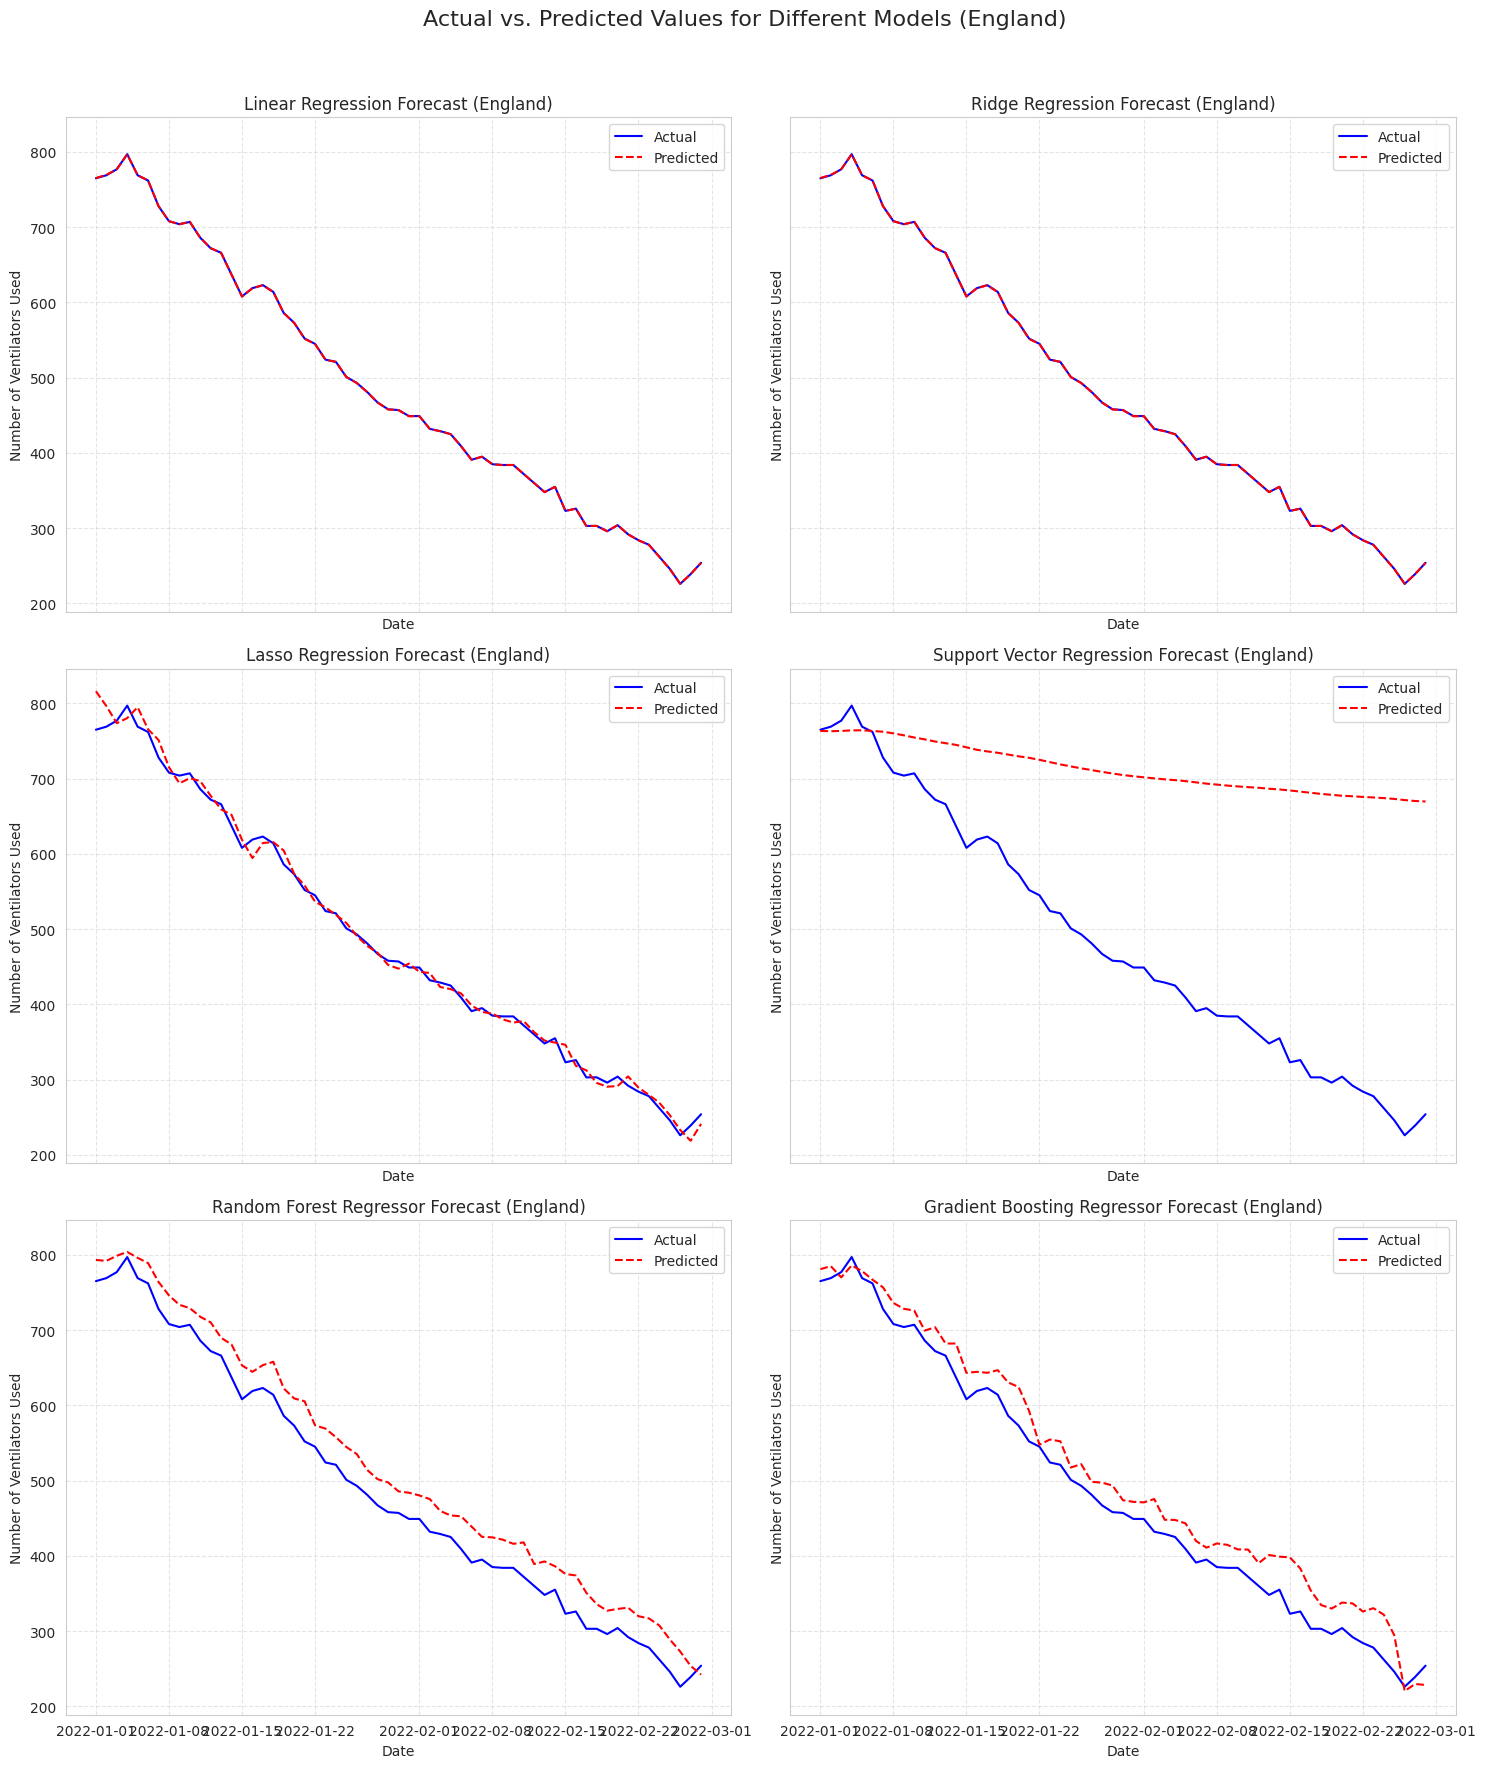

In [60]:
# Function to plot actual vs. predicted values for the testing data
def plot_actual_vs_predicted(model, X_test, y_test, model_name, ax):
    forecast = model.predict(X_test)
    ax.plot(y_test.index, y_test, label="Actual", color="blue")
    ax.plot(y_test.index, forecast, label="Predicted", color="red", linestyle="--")
    ax.set_title(f"{model_name} Forecast (England)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of Ventilators Used")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)


# Models and their names
models = [
    linear_reg_model,
    ridge_reg_model,
    lasso_reg_model,
    svr_model,
    random_forest_model,
    gradient_boosting_model,
]
model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "Support Vector Regression",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
]

# Plotting the actual vs. predicted values for all models
fig, axes = plt.subplots(3, 2, figsize=(15, 18), sharex=True, sharey=True)
for model, model_name, ax in zip(models, model_names, axes.flatten()):
    plot_actual_vs_predicted(model, X_test, y_test, model_name, ax)

plt.suptitle("Actual vs. Predicted Values for Different Models (England)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjusting layout to fit the title
plt.show()

In [61]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Gradient Boosting Regressor
param_grid_gb = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 4, 6],
}

# Creating the Gradient Boosting model
gb_model = GradientBoostingRegressor()

# Performing grid search with cross-validation for Gradient Boosting Regressor
grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring="neg_mean_absolute_error",
)
grid_search_gb.fit(X_train, y_train)

# Getting the best hyperparameters
best_params_gb = grid_search_gb.best_params_
best_params_gb

Fitting 3 folds for each of 81 candidates, totalling 243 fits


{'learning_rate': 0.1,
 'max_depth': 7,
 'min_samples_split': 2,
 'n_estimators': 150}

In [62]:
# Training and evaluating the Gradient Boosting Regressor with the best hyperparameters
best_gb_model = GradientBoostingRegressor(**best_params_gb)
metrics_df_tuned = train_evaluate_model(
    best_gb_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Tuned Gradient Boosting Regressor",
    metrics_df,
)

# Displaying the updated metrics DataFrame, including the tuned Gradient Boosting Regressor
metrics_df_tuned

,Model,MAE,MSE,RMSE,Forecast Bias
0,ARIMA (ENGLAND),539.861977,358461.128351,598.716234,539.861977
1,Linear Regression,0.126995,0.025989,0.161212,-0.062473
2,Ridge Regression,0.126848,0.025970,0.161152,-0.062076
3,Lasso Regression,9.309077,157.411330,12.546367,2.102047
4,Support Vector Regression,228.817519,70131.206397,264.822972,226.819380
5,Random Forest Regressor,34.933220,1312.622939,36.230139,34.531864
6,Gradient Boosting Regressor,29.787948,1112.050783,33.347425,27.793603
7,Tuned Gradient Boosting Regressor,8.361555,102.782833,10.138187,2.007068


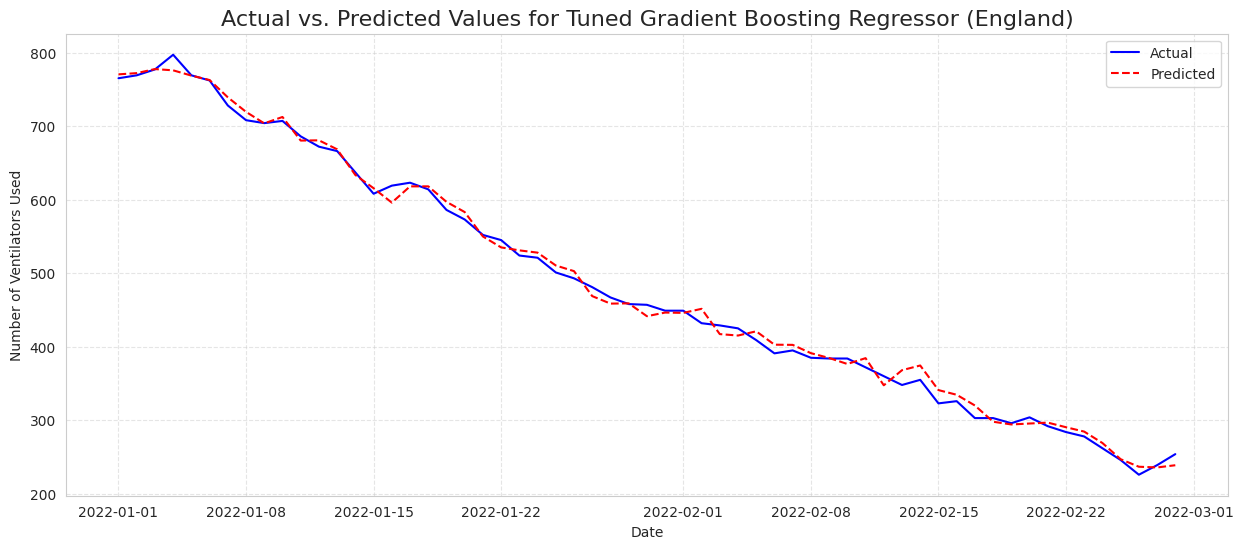

In [63]:
# Plotting the actual vs. predicted values for the tuned Gradient Boosting Regressor
plt.figure(figsize=(15, 6))
plot_actual_vs_predicted(
    best_gb_model, X_test, y_test, "Tuned Gradient Boosting Regressor", plt.gca()
)
plt.title(
    "Actual vs. Predicted Values for Tuned Gradient Boosting Regressor (England)",
    fontsize=16,
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [25]:
# Function to create features using Time Delay Embedding, Fourier terms, temporal features, EWMA, and Temporal Embedding
def create_advanced_features(series, lags=5, fourier_terms=5, ewma_span=5):
    features = pd.DataFrame({"y": series})

    # Time Delay Embedding (lagged features)
    for i in range(1, lags + 1):
        features[f"lag_{i}"] = series.shift(i)

    # Fourier terms (sine and cosine transformations)
    fourier_transform = fft(series)
    for i in range(fourier_terms):
        features[f"fourier_real_{i}"] = fourier_transform.real[i]
        features[f"fourier_imag_{i}"] = fourier_transform.imag[i]

    # Temporal features (day-of-week, month)
    features["day_of_week"] = series.index.dayofweek
    features["month"] = series.index.month

    # Exponentially Weighted Moving Averages (EWMA)
    features["ewma"] = series.ewm(span=ewma_span).mean()

    # Dropping any rows with missing values (due to lags)
    features = features.dropna()
    return features


# Creating advanced features for the "ENGLAND" series using the entire dataset
advanced_features = create_advanced_features(data_transposed["ENGLAND"])

# Splitting the data into training and testing sets based on the specified dates
X_advanced_train = advanced_features.loc["2020-01-01":"2021-12-31"].drop("y", axis=1)
y_advanced_train = advanced_features.loc["2020-01-01":"2021-12-31"]["y"]
X_advanced_test = advanced_features.loc["2022-01-01":"2022-02-28"].drop("y", axis=1)
y_advanced_test = advanced_features.loc["2022-01-01":"2022-02-28"]["y"]

# Displaying the first few rows of the transformed data with advanced features
X_advanced_train.head(), y_advanced_train.head()

(            lag_1  lag_2  lag_3  lag_4  lag_5  fourier_real_0  fourier_imag_0  \
 2020-08-06   63.0   65.0   67.0   72.0   74.0        486247.0            -0.0   
 2020-08-07   61.0   63.0   65.0   67.0   72.0        486247.0            -0.0   
 2020-08-08   57.0   61.0   63.0   65.0   67.0        486247.0            -0.0   
 2020-08-09   55.0   57.0   61.0   63.0   65.0        486247.0            -0.0   
 2020-08-10   56.0   55.0   57.0   61.0   63.0        486247.0            -0.0   
 
             fourier_real_1  fourier_imag_1  fourier_real_2  fourier_imag_2  \
 2020-08-06   -50765.293273  -136125.444987  -228746.885731    59814.651823   
 2020-08-07   -50765.293273  -136125.444987  -228746.885731    59814.651823   
 2020-08-08   -50765.293273  -136125.444987  -228746.885731    59814.651823   
 2020-08-09   -50765.293273  -136125.444987  -228746.885731    59814.651823   
 2020-08-10   -50765.293273  -136125.444987  -228746.885731    59814.651823   
 
             fourier_real_3  f

In [28]:
# Creating and training the Random Forest model with advanced features (TDE, Fourier terms, Temporal, EWMA)
random_forest_model_advanced = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model_advanced.fit(X_advanced_train, y_advanced_train)

# Forecasting the "ENGLAND" series for the testing period using Random Forest with advanced features
rf_advanced_forecast_england = random_forest_model_advanced.predict(X_advanced_test)

# Evaluating the Random Forest forecast using MAE, MSE, RMSE, and Forecast Bias
rf_advanced_mae_england = mean_absolute_error(
    y_advanced_test, rf_advanced_forecast_england
)
rf_advanced_mse_england = mean_squared_error(
    y_advanced_test, rf_advanced_forecast_england
)
rf_advanced_rmse_england = np.sqrt(rf_advanced_mse_england)
rf_advanced_bias_england = (rf_advanced_forecast_england - y_advanced_test).mean()

# Displaying the Random Forest forecast and evaluation metrics for "ENGLAND" with advanced features
rf_advanced_forecast_england[
    :5
], rf_advanced_mae_england, rf_advanced_mse_england, rf_advanced_rmse_england, rf_advanced_bias_england

(array([781.18, 773.85, 775.18, 775.77, 786.03]),
 13.325932203389831,
 255.84959152542368,
 15.995299044576306,
 9.28694915254237)

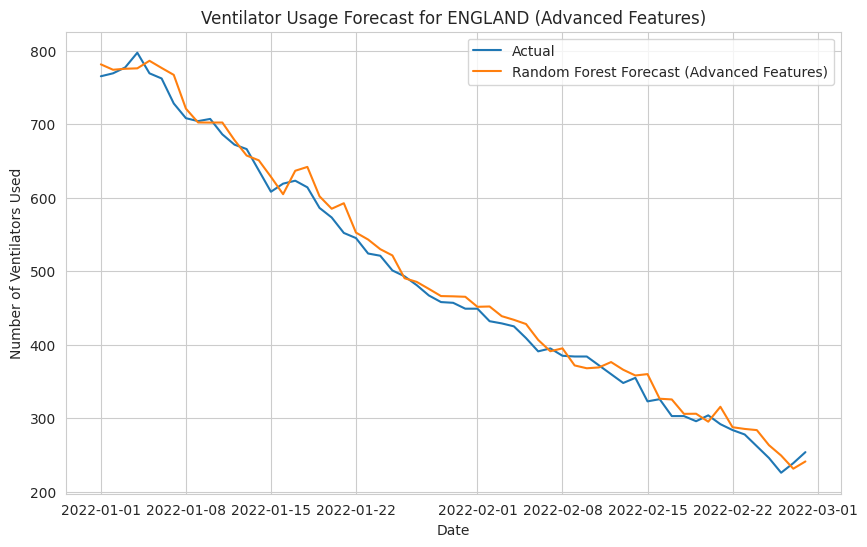

In [29]:
# Plotting the actual values and Random Forest forecast with advanced features for "ENGLAND"
plt.figure(figsize=(10, 6))
plt.plot(y_advanced_test.index, y_advanced_test, label="Actual")
plt.plot(
    y_advanced_test.index,
    rf_advanced_forecast_england,
    label="Random Forest Forecast (Advanced Features)",
)
plt.title("Ventilator Usage Forecast for ENGLAND (Advanced Features)")
plt.xlabel("Date")
plt.ylabel("Number of Ventilators Used")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Function to apply various machine learning algorithms and evaluate the forecasts
def compare_ml_algorithms(X_train, y_train, X_test, y_test):
    # List of machine learning models to apply
    models = [
        ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
        (
            "Gradient Boosting",
            GradientBoostingRegressor(n_estimators=100, random_state=42),
        ),
        ("Support Vector Regression", SVR(kernel="linear")),
        ("Linear Regression", LinearRegression()),
        ("Ridge Regression", Ridge()),
        ("Lasso Regression", Lasso()),
    ]

    # DataFrame to store the evaluation results
    results_df = pd.DataFrame(columns=["Algorithm", "MAE", "MSE", "RMSE", "Bias"])

    # Applying each model and evaluating the forecasts
    for name, model in models:
        model.fit(X_train, y_train)
        forecast = model.predict(X_test)
        mae = mean_absolute_error(y_test, forecast)
        mse = mean_squared_error(y_test, forecast)
        rmse = np.sqrt(mse)
        bias = (forecast - y_test).mean()
        results_df.loc[len(results_df)] = [name, mae, mse, rmse, bias]

    return results_df


# Applying the function to the "ENGLAND" series with advanced features and displaying the results
ml_comparison_results = compare_ml_algorithms(
    X_advanced_train, y_advanced_train, X_advanced_test, y_advanced_test
)
ml_comparison_results

/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.690e+04, tolerance: 3.611e+04
  model = cd_fast.enet_coordinate_descent(


,Algorithm,MAE,MSE,RMSE,Bias
0,Random Forest,13.325932,2.558496e+02,15.995299,9.286949
1,Gradient Boosting,11.262767,1.962512e+02,14.008968,1.724015
2,Support Vector Regression,8672.868839,1.133494e+08,10646.567123,-7695.996393
3,Linear Regression,4.225803,3.397331e+01,5.828663,-2.160791
4,Ridge Regression,4.225734,3.397251e+01,5.828594,-2.160416
5,Lasso Regression,9.095620,1.304283e+02,11.420522,0.233468


In [32]:
# Function to predict using Linear Regression for different time horizons
def predict_time_horizons(X_train, y_train, X_test, y_test, time_horizons):
    # Training the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # DataFrame to store the prediction results for different time horizons
    predictions_df = pd.DataFrame(
        columns=["Time Horizon", "MAE", "MSE", "RMSE", "Bias"]
    )

    # Predicting for each time horizon and evaluating the forecasts
    for horizon in time_horizons:
        forecast = model.predict(X_test.head(horizon))
        mae = mean_absolute_error(y_test.head(horizon), forecast)
        mse = mean_squared_error(y_test.head(horizon), forecast)
        rmse = np.sqrt(mse)
        bias = (forecast - y_test.head(horizon)).mean()
        predictions_df.loc[len(predictions_df)] = [
            f"{horizon} days",
            mae,
            mse,
            rmse,
            bias,
        ]

    return predictions_df


# Time horizons to predict (in days): 1 week, 2 weeks, 1 month, 2 months
time_horizons = [7, 14, 30, 60]

# Predicting for different time horizons and displaying the results
time_horizon_results = predict_time_horizons(
    X_advanced_train, y_advanced_train, X_advanced_test, y_advanced_test, time_horizons
)
time_horizon_results

,Time Horizon,MAE,MSE,RMSE,Bias
0,7 days,3.563194,20.928155,4.574730,-1.890019
1,14 days,6.009607,66.384119,8.147645,-3.667746
2,30 days,5.111779,48.099538,6.935383,-2.461724
3,60 days,4.225803,33.973309,5.828663,-2.160791


In [33]:
# Function to extract feature importance (coefficients) from the Linear Regression model
def linear_regression_feature_importance(X_train, y_train):
    # Training the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Creating a DataFrame to store the feature importance
    feature_importance_df = pd.DataFrame(
        {"Feature": X_train.columns, "Importance": model.coef_}
    )

    # Sorting the features by absolute importance
    feature_importance_df["Abs_Importance"] = feature_importance_df["Importance"].abs()
    feature_importance_df = feature_importance_df.sort_values(
        by="Abs_Importance", ascending=False
    ).drop("Abs_Importance", axis=1)

    return feature_importance_df


# Extracting and displaying the feature importance for the "ENGLAND" series using Linear Regression
feature_importance_results = linear_regression_feature_importance(
    X_advanced_train, y_advanced_train
)
feature_importance_results

,Feature,Importance
8,fourier_imag_1,-18.100989
11,fourier_real_3,18.100989
9,fourier_real_2,18.100989
12,fourier_imag_3,9.050495
10,fourier_imag_2,-9.050495
7,fourier_real_1,-4.525247
17,ewma,2.669348
13,fourier_real_4,1.131312
4,lag_5,-0.522779
1,lag_2,-0.365523


## Multivariate Time Series Model

In [35]:
# Function to create multivariate features using Time Delay Embedding, Fourier terms, temporal features, EWMA, and Temporal Embedding
def create_multivariate_features(data, lags=5, fourier_terms=5, ewma_span=5):
    multivariate_features = pd.DataFrame(index=data.index)

    # Looping through each region to create features
    for region in data.columns:
        region_features = create_advanced_features(
            data[region], lags=lags, fourier_terms=fourier_terms, ewma_span=ewma_span
        )
        region_features.columns = [f"{region}_{col}" for col in region_features.columns]
        multivariate_features = pd.concat(
            [multivariate_features, region_features], axis=1
        )

    return multivariate_features.dropna()

In [37]:
# Creating multivariate features for all regions using the entire dataset
multivariate_features = create_multivariate_features(data_transposed)
# Extracting the region names from the data
regions = data_transposed.columns.tolist()

# Splitting the multivariate data into training and testing sets based on the specified dates
X_multivariate_train = multivariate_features.loc["2020-01-01":"2021-12-31"].drop(
    columns=[f"{region}_y" for region in regions]
)
y_multivariate_train = multivariate_features.loc["2020-01-01":"2021-12-31"][
    [f"{region}_y" for region in regions]
]
X_multivariate_test = multivariate_features.loc["2022-01-01":"2022-02-28"].drop(
    columns=[f"{region}_y" for region in regions]
)
y_multivariate_test = multivariate_features.loc["2022-01-01":"2022-02-28"][
    [f"{region}_y" for region in regions]
]

# Displaying the first few rows of the transformed multivariate data with advanced features
X_multivariate_train.head(), y_multivariate_train.head()

(            ENGLAND_lag_1  ENGLAND_lag_2  ENGLAND_lag_3  ENGLAND_lag_4  \
 2020-08-06           63.0           65.0           67.0           72.0   
 2020-08-07           61.0           63.0           65.0           67.0   
 2020-08-08           57.0           61.0           63.0           65.0   
 2020-08-09           55.0           57.0           61.0           63.0   
 2020-08-10           56.0           55.0           57.0           61.0   
 
             ENGLAND_lag_5  ENGLAND_fourier_real_0  ENGLAND_fourier_imag_0  \
 2020-08-06           74.0                486247.0                    -0.0   
 2020-08-07           72.0                486247.0                    -0.0   
 2020-08-08           67.0                486247.0                    -0.0   
 2020-08-09           65.0                486247.0                    -0.0   
 2020-08-10           63.0                486247.0                    -0.0   
 
             ENGLAND_fourier_real_1  ENGLAND_fourier_imag_1  \
 2020-08-06    

In [38]:
# Function to apply various machine learning algorithms to the multivariate forecasting task for each region individually
def compare_multivariate_ml_algorithms_individual(
    X_train, y_train, X_test, y_test, regions
):
    # List of machine learning models to apply
    models = [
        ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
        (
            "Gradient Boosting",
            GradientBoostingRegressor(n_estimators=100, random_state=42),
        ),
        ("Linear Regression", LinearRegression()),
        ("Ridge Regression", Ridge()),
        ("Lasso Regression", Lasso()),
    ]

    # DataFrame to store the evaluation results
    results_df = pd.DataFrame(
        columns=["Algorithm", "Region", "MAE", "MSE", "RMSE", "Bias"]
    )

    # Applying each model to each region and evaluating the forecasts
    for region in regions:
        for name, model in models:
            model.fit(X_train, y_train[f"{region}_y"])
            forecast = model.predict(X_test)
            mae = mean_absolute_error(y_test[f"{region}_y"], forecast)
            mse = mean_squared_error(y_test[f"{region}_y"], forecast)
            rmse = np.sqrt(mse)
            bias = (forecast - y_test[f"{region}_y"]).mean()
            results_df.loc[len(results_df)] = [name, region, mae, mse, rmse, bias]

    return results_df


# Applying the function to the multivariate series with advanced features for individual regions and displaying the results
ml_multivariate_individual_comparison_results = (
    compare_multivariate_ml_algorithms_individual(
        X_multivariate_train,
        y_multivariate_train,
        X_multivariate_test,
        y_multivariate_test,
        regions,
    )
)
ml_multivariate_individual_comparison_results

/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.332e+04, tolerance: 3.611e+04
  model = cd_fast.enet_coordinate_descent(
/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.030e+03, tolerance: 3.674e+02
  model = cd_fast.enet_coordinate_descent(
/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

,Algorithm,Region,MAE,MSE,RMSE,Bias
0,Random Forest,ENGLAND,18.392881,463.853803,21.537265,16.348475
1,Gradient Boosting,ENGLAND,14.567588,334.316164,18.284315,-0.690703
2,Linear Regression,ENGLAND,5.172172,42.024970,6.482667,2.773034
3,Ridge Regression,ENGLAND,5.172049,42.024150,6.482604,2.773101
4,Lasso Regression,ENGLAND,7.085391,80.559235,8.975480,2.733751
5,Random Forest,East of England,4.342034,25.307349,5.030641,-0.613898
6,Gradient Boosting,East of England,5.489245,46.694234,6.833318,-1.720184
7,Linear Regression,East of England,1.508642,3.343226,1.828449,1.455047
8,Ridge Regression,East of England,1.508292,3.343084,1.828410,1.455139
9,Lasso Regression,East of England,1.907320,6.902537,2.627268,1.248589


In [39]:
from sklearn.model_selection import RandomizedSearchCV


# Function to perform hyperparameter tuning for Random Forest for multivariate forecasting (individual regions)
def hyperparameter_tuning_random_forest(X_train, y_train, regions):
    # Hyperparameter grid for Random Forest
    param_dist = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False],
    }

    # DataFrame to store the best hyperparameters for each region
    best_params_df = pd.DataFrame(columns=["Region", "Best Parameters"])

    # Performing Randomized Search for each region
    for region in regions:
        rf = RandomForestRegressor(random_state=42)
        rf_random_search = RandomizedSearchCV(
            estimator=rf,
            param_distributions=param_dist,
            n_iter=50,
            cv=3,
            verbose=2,
            random_state=42,
            n_jobs=-1,
        )
        rf_random_search.fit(X_train, y_train[f"{region}_y"])
        best_params_df.loc[len(best_params_df)] = [
            region,
            rf_random_search.best_params_,
        ]

    return best_params_df


# Performing hyperparameter tuning for Random Forest for each region and displaying the best parameters
best_rf_params = hyperparameter_tuning_random_forest(
    X_multivariate_train, y_multivariate_train, regions
)
best_rf_params

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.5s[CV] END bootstrap=False, max_depth=30, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.5s

[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.5s[CV] END bootstrap=False, max_depth=20, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.5s[CV] END bootstrap=False, max_depth=30, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=   0.5s


[CV] END bootstrap=False, max_depth=30, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.5s
[CV] END bootstrap=False, max_depth=30, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.5s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.

,Region,Best Parameters
0,ENGLAND,"{'n_estimators': 200, 'min_samples_split': 5, ..."
1,East of England,"{'n_estimators': 200, 'min_samples_split': 5, ..."
2,London,"{'n_estimators': 50, 'min_samples_split': 5, '..."
3,Midlands,"{'n_estimators': 50, 'min_samples_split': 2, '..."
4,North East and Yorkshire,"{'n_estimators': 100, 'min_samples_split': 10,..."
5,North West,"{'n_estimators': 100, 'min_samples_split': 10,..."
6,South East,"{'n_estimators': 50, 'min_samples_split': 10, ..."
7,South West,"{'n_estimators': 100, 'min_samples_split': 5, ..."


In [41]:
# Function to perform hyperparameter tuning for Random Forest for a single region
def hyperparameter_tuning_random_forest_single_region(
    X_train, y_train, region, n_iter=10
):
    # Hyperparameter grid for Random Forest
    param_dist = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False],
    }

    # Performing Randomized Search for the specified region
    rf = RandomForestRegressor(random_state=42)
    rf_random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1,
    )
    rf_random_search.fit(X_train, y_train[f"{region}_y"])

    return rf_random_search.best_params_


# Performing hyperparameter tuning for Random Forest for the "ENGLAND" region and getting the best parameters
region_to_tune = "ENGLAND"
best_rf_params_single_region = hyperparameter_tuning_random_forest_single_region(
    X_multivariate_train, y_multivariate_train, region_to_tune
)
best_rf_params_single_region

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.4s[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.4s

[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.5s
[CV] END bootstrap=False, max_depth=30, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.6s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.6s
[CV] END bootstrap=False, max_depth=30, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.6s
[CV] END bootstrap=False, max_depth=30, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   0.6s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_depth': 20,
 'bootstrap': True}

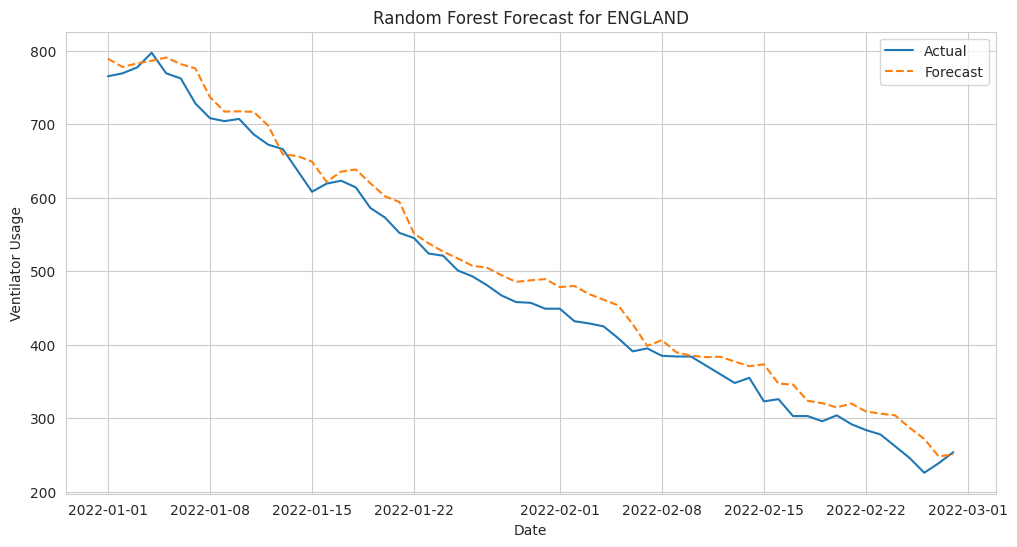

In [42]:
# Function to train Random Forest with the best hyperparameters and visualize the forecast
def train_and_visualize_random_forest(
    X_train, y_train, X_test, y_test, best_params, region
):
    # Creating the Random Forest model with the best hyperparameters
    rf_model = RandomForestRegressor(**best_params, random_state=42)
    rf_model.fit(X_train, y_train[f"{region}_y"])

    # Forecasting using the Random Forest model
    rf_forecast = rf_model.predict(X_test)

    # Plotting the actual vs. forecasted values
    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test[f"{region}_y"], label="Actual")
    plt.plot(y_test.index, rf_forecast, label="Forecast", linestyle="--")
    plt.title(f"Random Forest Forecast for {region}")
    plt.xlabel("Date")
    plt.ylabel("Ventilator Usage")
    plt.legend()
    plt.grid(True)
    plt.show()


# Training and visualizing the Random Forest model for the "ENGLAND" region using the best hyperparameters
train_and_visualize_random_forest(
    X_multivariate_train,
    y_multivariate_train,
    X_multivariate_test,
    y_multivariate_test,
    best_rf_params_single_region,
    region_to_tune,
)

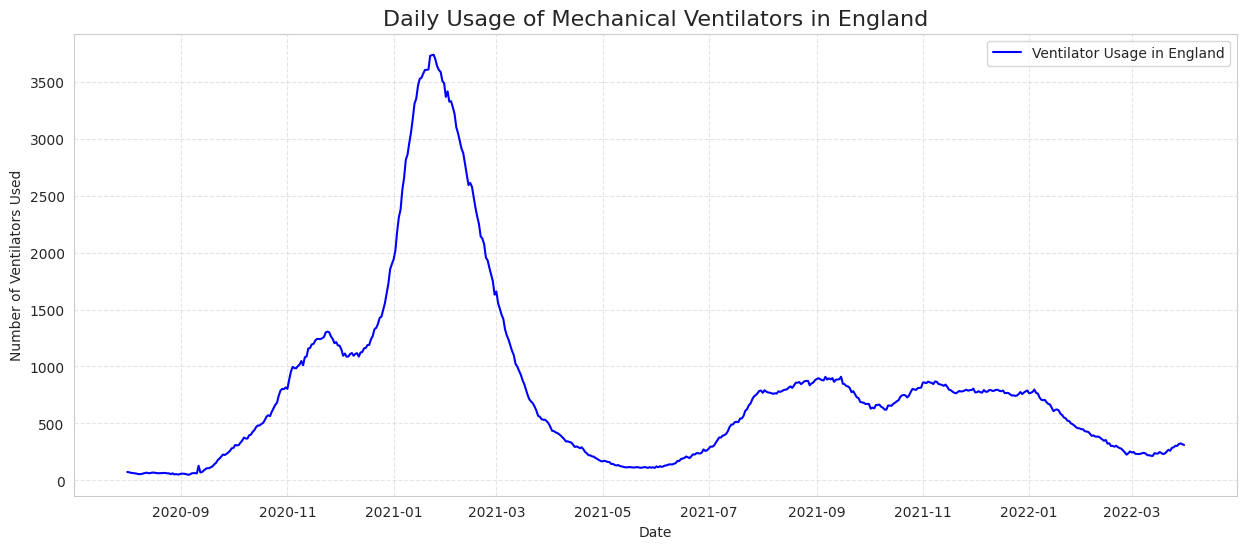

(-2.2674628314599836, 0.182676631047695)

In [66]:
from statsmodels.tsa.stattools import adfuller

# Extracting the "ENGLAND" series
england_series = data_transposed["ENGLAND"]

# Plotting the "ENGLAND" series
plt.figure(figsize=(15, 6))
plt.plot(england_series, label="Ventilator Usage in England", color="blue")
plt.title("Daily Usage of Mechanical Ventilators in England", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Ventilators Used")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Applying the Augmented Dickey-Fuller test to check for stationarity
adf_result = adfuller(england_series)
adf_statistic, p_value = adf_result[0], adf_result[1]

# Returning the ADF test result
adf_statistic, p_value

The Augmented Dickey-Fuller (ADF) test gives us a test statistic of approximately -2.27 and a p-value of approximately 0.18. Since the p-value is greater than the typical significance level of 0.05, we fail to reject the null hypothesis of the ADF test, indicating that the series may contain a unit root and is non-stationary.

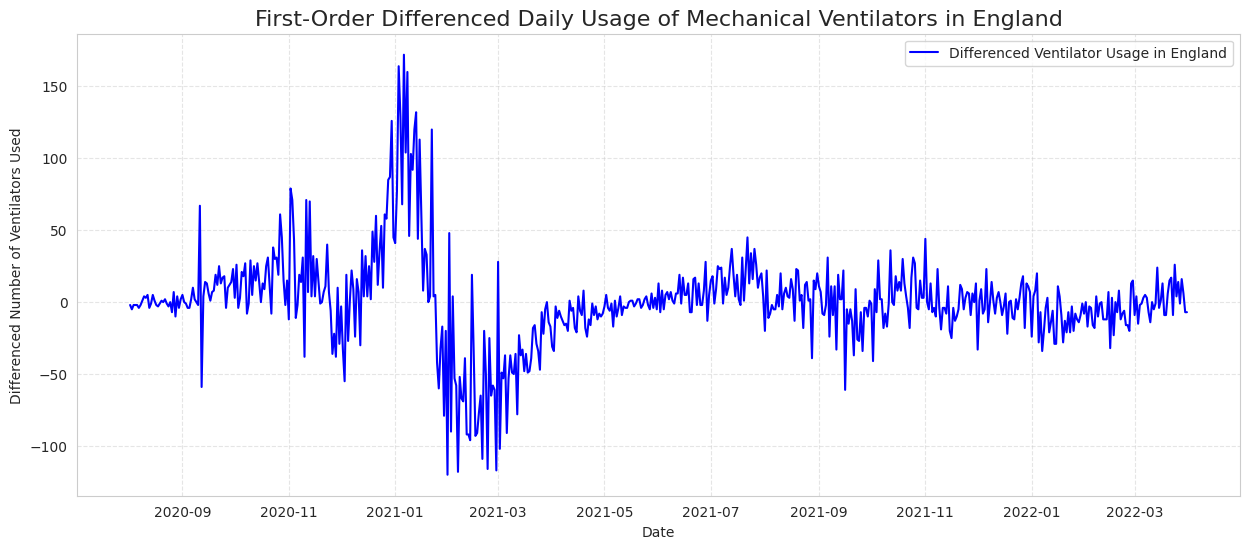

(-4.628042176288799, 0.00011463931270731123)

In [67]:
# Applying first-order differencing to the "ENGLAND" series
england_differenced = england_series.diff().dropna()

# Plotting the differenced series
plt.figure(figsize=(15, 6))
plt.plot(
    england_differenced, label="Differenced Ventilator Usage in England", color="blue"
)
plt.title(
    "First-Order Differenced Daily Usage of Mechanical Ventilators in England",
    fontsize=16,
)
plt.xlabel("Date")
plt.ylabel("Differenced Number of Ventilators Used")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Re-applying the Augmented Dickey-Fuller test to the differenced series
adf_result_differenced = adfuller(england_differenced)
adf_statistic_differenced, p_value_differenced = (
    adf_result_differenced[0],
    adf_result_differenced[1],
)

# Returning the ADF test result for the differenced series
adf_statistic_differenced, p_value_differenced

The first-order differenced series is plotted above, and it appears to have more constant mean and variance.

The Augmented Dickey-Fuller (ADF) test for the differenced series gives us a test statistic of approximately -4.63 and a p-value of approximately 
1.15
×
1
0
−
4
1.15×10 
−4
 . Since the p-value is less than the typical significance level of 0.05, we can reject the null hypothesis of the ADF test, indicating that the differenced series is stationary.

- We detected non-stationarity in the original "ENGLAND" series.
- We applied first-order differencing to achieve stationarity.
- The differenced series passed the ADF test for stationarity.

The plot of the first-order differenced series doesn't show any apparent linear or nonlinear trend. Since we applied differencing to handle non-stationarity earlier, it's likely that this step also removed any underlying trend.

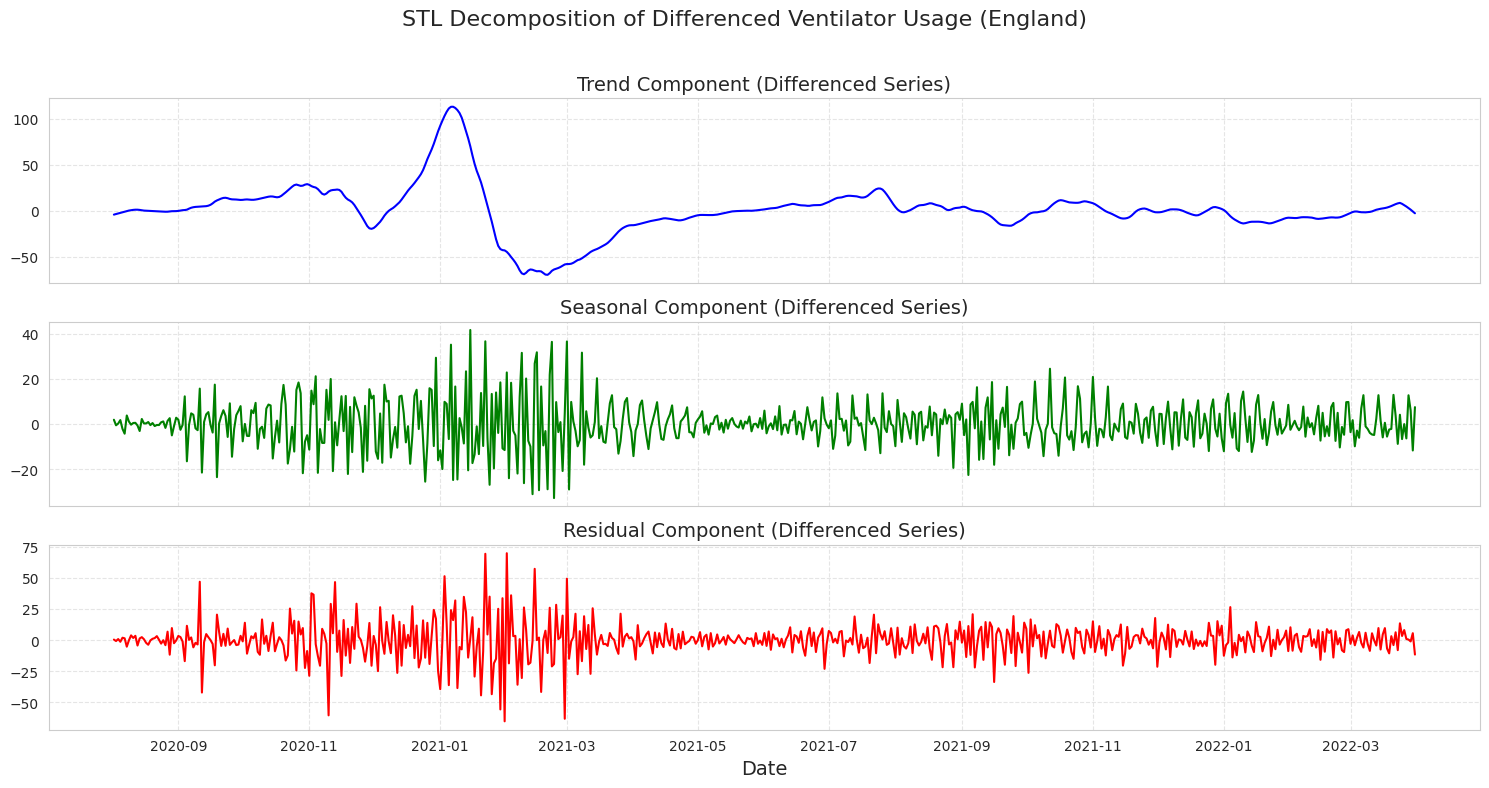

In [69]:
# Applying STL decomposition to the differenced "ENGLAND" series
# Using seasonal=7 to consider weekly seasonality
stl_decomposition_differenced = STL(england_differenced, seasonal=7).fit()

# Extracting the trend, seasonal, and residual components
trend_differenced = stl_decomposition_differenced.trend
seasonal_differenced = stl_decomposition_differenced.seasonal
residual_differenced = stl_decomposition_differenced.resid

# Plotting the STL decomposition
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
axes[0].plot(trend_differenced, color="blue")
axes[0].set_title("Trend Component (Differenced Series)", fontsize=14)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(seasonal_differenced, color="green")
axes[1].set_title("Seasonal Component (Differenced Series)", fontsize=14)
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].plot(residual_differenced, color="red")
axes[2].set_title("Residual Component (Differenced Series)", fontsize=14)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("STL Decomposition of Differenced Ventilator Usage (England)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjusting layout to fit the title
plt.show()

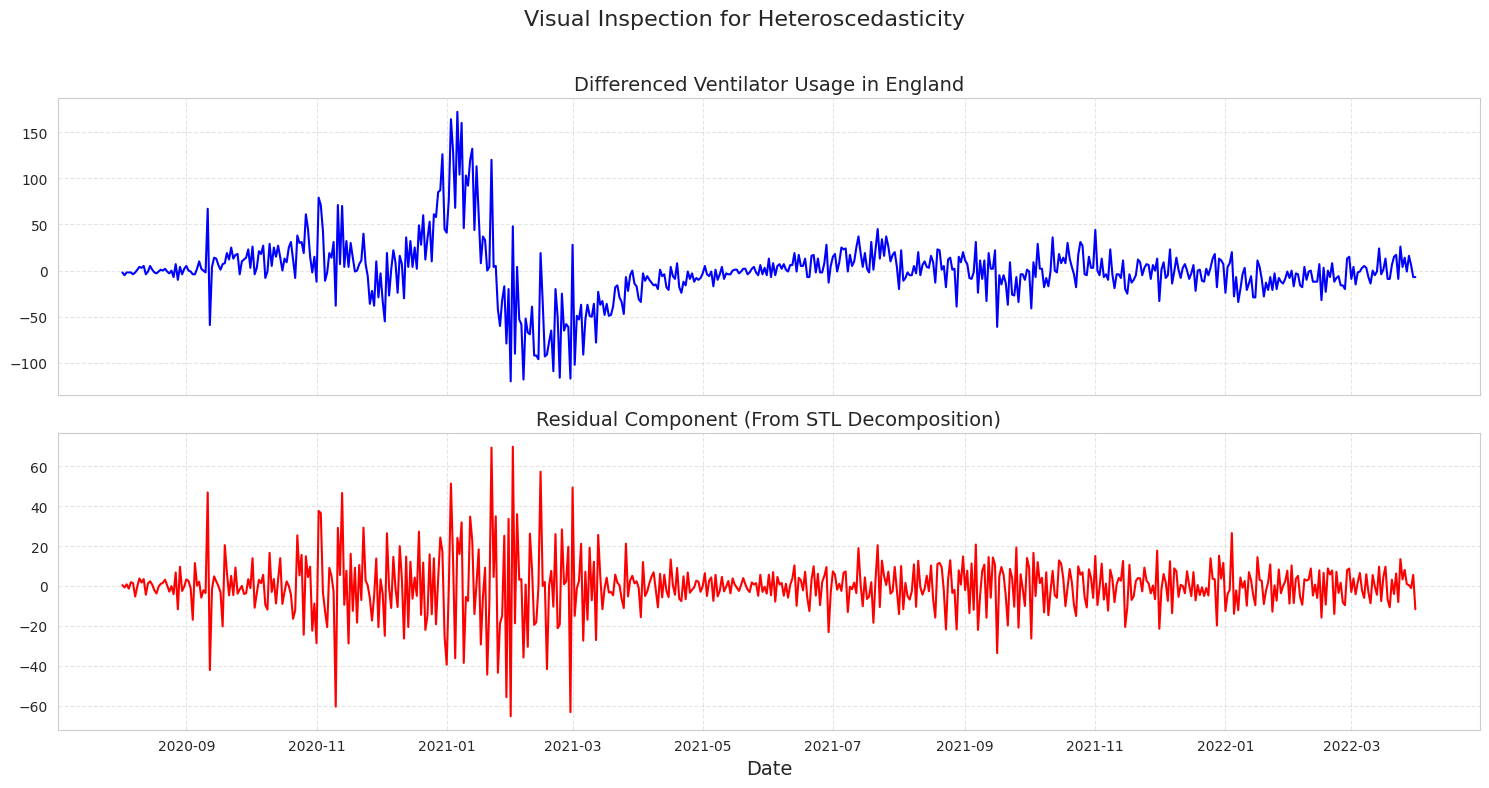

In [70]:
# Plotting the differenced series and its residual component to visually inspect for heteroscedasticity
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(england_differenced, color="blue")
axes[0].set_title("Differenced Ventilator Usage in England", fontsize=14)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(residual_differenced, color="red")
axes[1].set_title("Residual Component (From STL Decomposition)", fontsize=14)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Visual Inspection for Heteroscedasticity", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjusting layout to fit the title
plt.show()

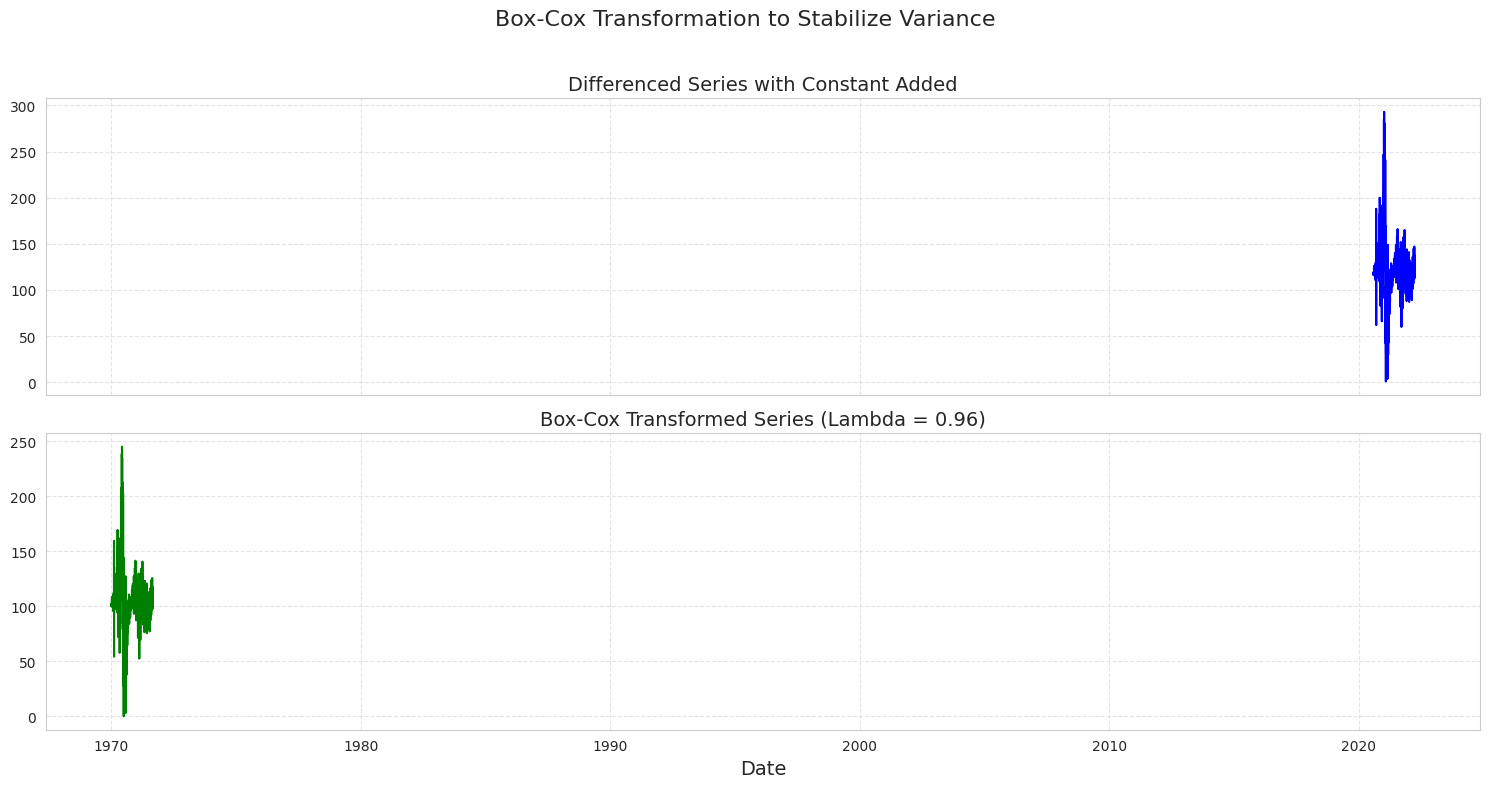

0.9627479009560822

In [71]:
from scipy.stats import boxcox

# Adding a constant to make the series positive
constant_added_series = england_differenced - england_differenced.min() + 1

# Applying the Box-Cox transformation
boxcox_transformed_series, lambda_value = boxcox(constant_added_series)

# Plotting the original and Box-Cox transformed series
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(constant_added_series, color="blue")
axes[0].set_title("Differenced Series with Constant Added", fontsize=14)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(boxcox_transformed_series, color="green")
axes[1].set_title(
    "Box-Cox Transformed Series (Lambda = {:.2f})".format(lambda_value), fontsize=14
)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Box-Cox Transformation to Stabilize Variance", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjusting layout to fit the title
plt.show()

# Returning the lambda value of the Box-Cox transformation
lambda_value

From the visual inspection, there doesn't appear to be a clear pattern of changing variance (such as a funnel shape) in either plot. The variance seems to be relatively constant over time.

However, visual inspection alone may not be sufficient to detect subtle heteroscedasticity. We can also consider applying statistical tests or transformations to further analyze and correct for potential heteroscedasticity.

The Box-Cox transformation has been applied to the differenced series, and the results are plotted above. The top plot shows the original differenced series (with a constant added to make it positive), while the bottom plot shows the Box-Cox transformed series.

The lambda value of the Box-Cox transformation is approximately 0.96. A lambda value close to 1 suggests that the transformation is close to identity, meaning that the original series did not require substantial transformation to stabilize the variance.

In [72]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Creating a lagged version of the series (using lag 1) for the regression model
lagged_series = england_differenced.shift(1).dropna()
X = sm.add_constant(lagged_series)
y = england_differenced[1:]

# Fitting a simple regression model using the lagged series
model = sm.OLS(y, X).fit()

# Conducting the Breusch-Pagan test for heteroscedasticity
bp_test_result = het_breuschpagan(model.resid, model.model.exog)

# Returning the result of the Breusch-Pagan test
bp_test_statistic, bp_test_pvalue = bp_test_result[:2]
bp_test_statistic, bp_test_pvalue

(0.5238076669395448, 0.469221943743215)

The result of the Breusch-Pagan test for heteroscedasticity is as follows:

Test Statistic: 
- 0.524

P-value: 
- 0.469

The p-value is well above the common significance level of 0.05, leading us to fail to reject the null hypothesis of constant variance (homoscedasticity). This result, along with the visual inspection and the Box-Cox transformation, provides evidence that heteroscedasticity is not a significant issue in the series.

Summary:
1. Trends: Successfully removed through differencing.
2. Seasonality: Detected and can be modeled directly or corrected through transformations.
3. Heteroscedasticity: Not detected through visual inspection, transformation, or statistical testing.

In [73]:
# Function to apply all feature engineering techniques to a given series
def apply_feature_engineering(series, max_lag, frequency, k_terms, span_values):
    # Time Delay Embedding
    time_delay_embedding = create_time_delay_embedding(series, max_lag)
    # Fourier Terms
    fourier_terms = create_fourier_terms(series, frequency, k_terms)
    # Temporal Features
    temporal_features = create_temporal_features(series)
    # EWMA Features
    ewma_features = create_ewma_features(series, span_values)
    # Combining all features
    combined_features = pd.concat(
        [
            time_delay_embedding,
            fourier_terms.drop(columns="Original"),
            temporal_features.drop(columns="Original"),
            ewma_features.drop(columns="Original"),
        ],
        axis=1,
    ).dropna()

    return combined_features


# Applying feature engineering to the "ENGLAND" series
england_series = data_transposed["ENGLAND"]
england_features = apply_feature_engineering(
    england_series, max_lag, frequency, k_terms, span_values
)

# Splitting the features into training and testing sets based on the specified dates
X_train = england_features.loc["2020-01-01":"2021-12-31"].drop(columns="Original")
y_train = england_features.loc["2020-01-01":"2021-12-31"]["Original"]
X_test = england_features.loc["2022-01-01":"2022-02-28"].drop(columns="Original")
y_test = england_features.loc["2022-01-01":"2022-02-28"]["Original"]

# Displaying the first few rows of the training features
X_train.head(), y_train.head()

/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  temporal_data['Week_of_Year'] = series.index.weekofyear


(            Lag_1  Lag_2  Lag_3  Lag_4  Lag_5     Cos_1         Sin_1  \
 2020-08-06   63.0   65.0   67.0   72.0   74.0 -0.222521 -9.749279e-01   
 2020-08-07   61.0   63.0   65.0   67.0   72.0  0.623490 -7.818315e-01   
 2020-08-08   57.0   61.0   63.0   65.0   67.0  1.000000 -2.449294e-16   
 2020-08-09   55.0   57.0   61.0   63.0   65.0  0.623490  7.818315e-01   
 2020-08-10   56.0   55.0   57.0   61.0   63.0 -0.222521  9.749279e-01   
 
                Cos_2         Sin_2     Cos_3         Sin_3  Day_of_Week  \
 2020-08-06 -0.900969  4.338837e-01  0.623490  7.818315e-01            3   
 2020-08-07 -0.222521 -9.749279e-01 -0.900969 -4.338837e-01            4   
 2020-08-08  1.000000 -4.898587e-16  1.000000 -7.347881e-16            5   
 2020-08-09 -0.222521  9.749279e-01 -0.900969  4.338837e-01            6   
 2020-08-10 -0.900969 -4.338837e-01  0.623490 -7.818315e-01            0   
 
             Month  Quarter  Day_of_Year  Week_of_Year     EWMA_3     EWMA_7  \
 2020-08-06     

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# Function to train and evaluate a given model
def train_evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    bias = np.mean(predictions - y_test)
    return mae, mse, rmse, bias


# Dictionary to store the results
results = {}

# List of models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Support Vector Regression": SVR(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
}

# Training and evaluating the models
for model_name, model in models.items():
    mae, mse, rmse, bias = train_evaluate_model(model, X_train, y_train, X_test, y_test)
    results[model_name] = [mae, mse, rmse, bias]

# Creating a DataFrame to store the results
metrics_df = pd.DataFrame(results, index=["MAE", "MSE", "RMSE", "Bias"]).transpose()
metrics_df

/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.466e+04, tolerance: 3.611e+04
  model = cd_fast.enet_coordinate_descent(


,MAE,MSE,RMSE,Bias
Linear Regression,0.126995,0.025989,0.161212,-0.062473
Ridge Regression,0.126848,0.025970,0.161152,-0.062076
Lasso Regression,9.309077,157.411330,12.546367,2.102047
Support Vector Regression,228.817519,70131.206397,264.822972,226.819380
Random Forest Regressor,69.653051,5140.697808,71.698660,69.141864
Gradient Boosting Regressor,30.286847,1123.347675,33.516379,28.447692


Observations:
Linear Regression and Ridge Regression achieved the lowest error metrics, indicating that they performed well on the testing data.
Lasso Regression showed a convergence warning, and the performance was not as good, likely due to the need for hyperparameter tuning.
Support Vector Regression showed poor performance, possibly requiring hyperparameter tuning and kernel selection.
Random Forest Regressor and Gradient Boosting Regressor performed better than Lasso and SVR but still not as well as Linear and Ridge Regression.

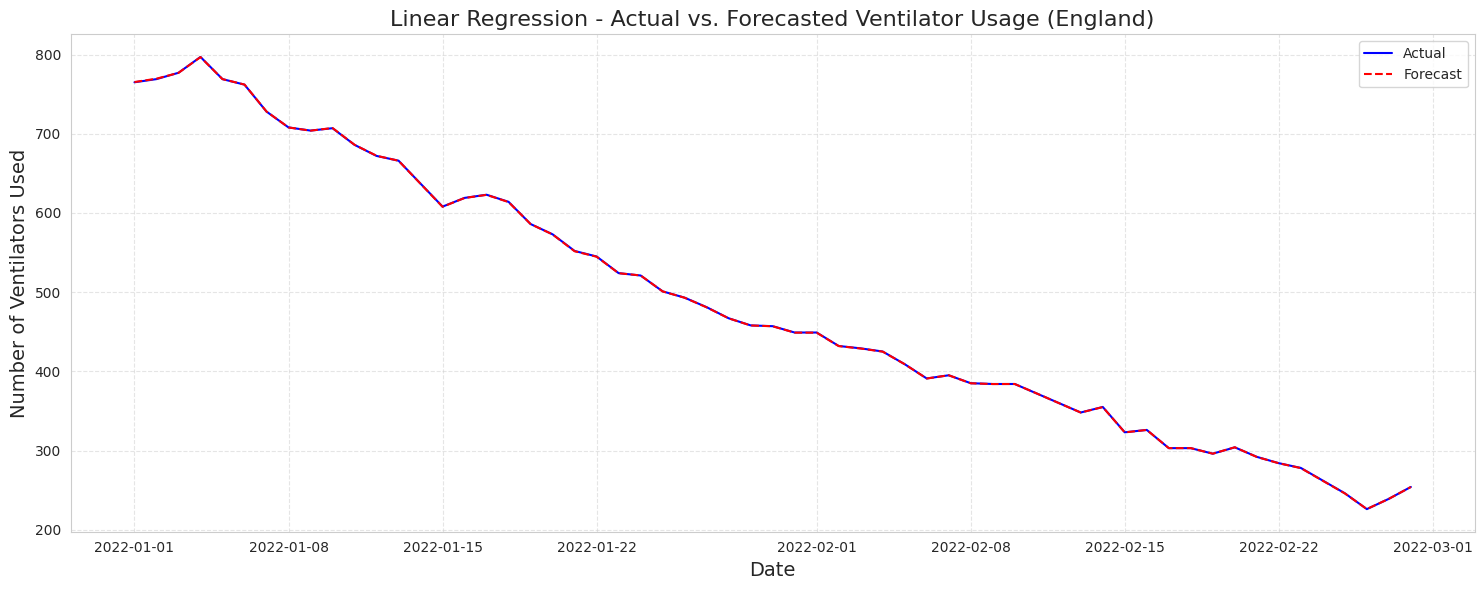

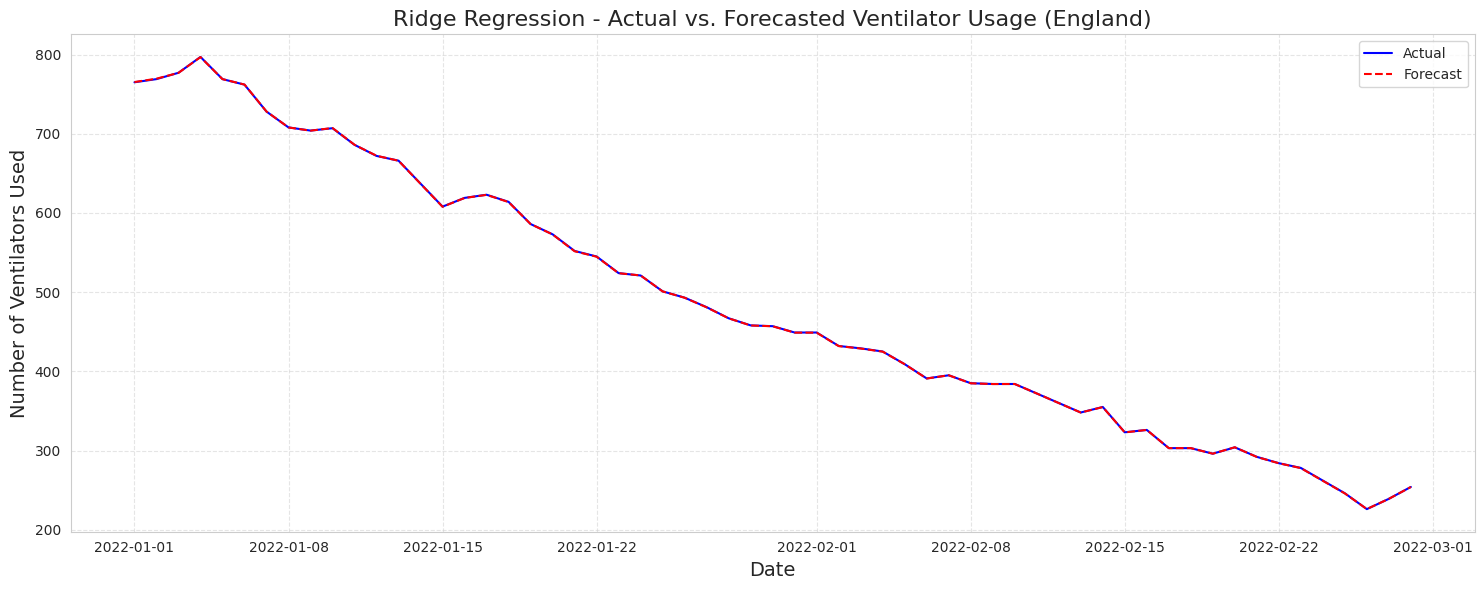

/home/michaelajao/miniconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.466e+04, tolerance: 3.611e+04
  model = cd_fast.enet_coordinate_descent(


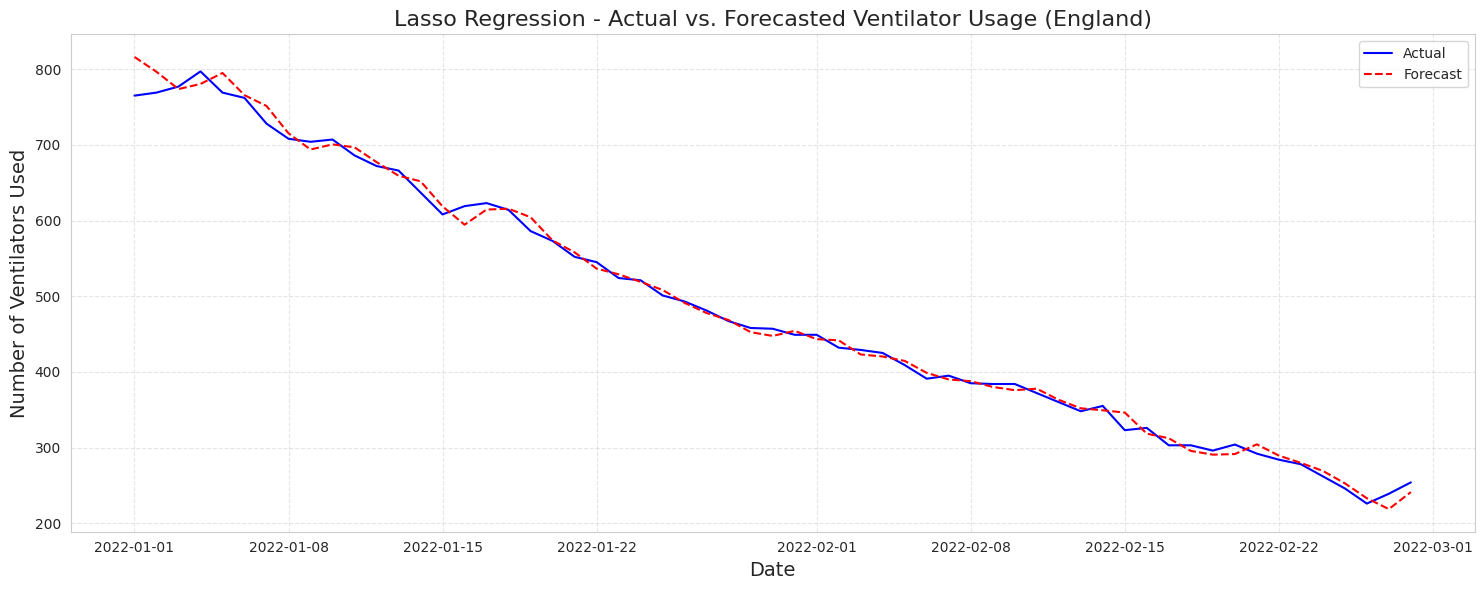

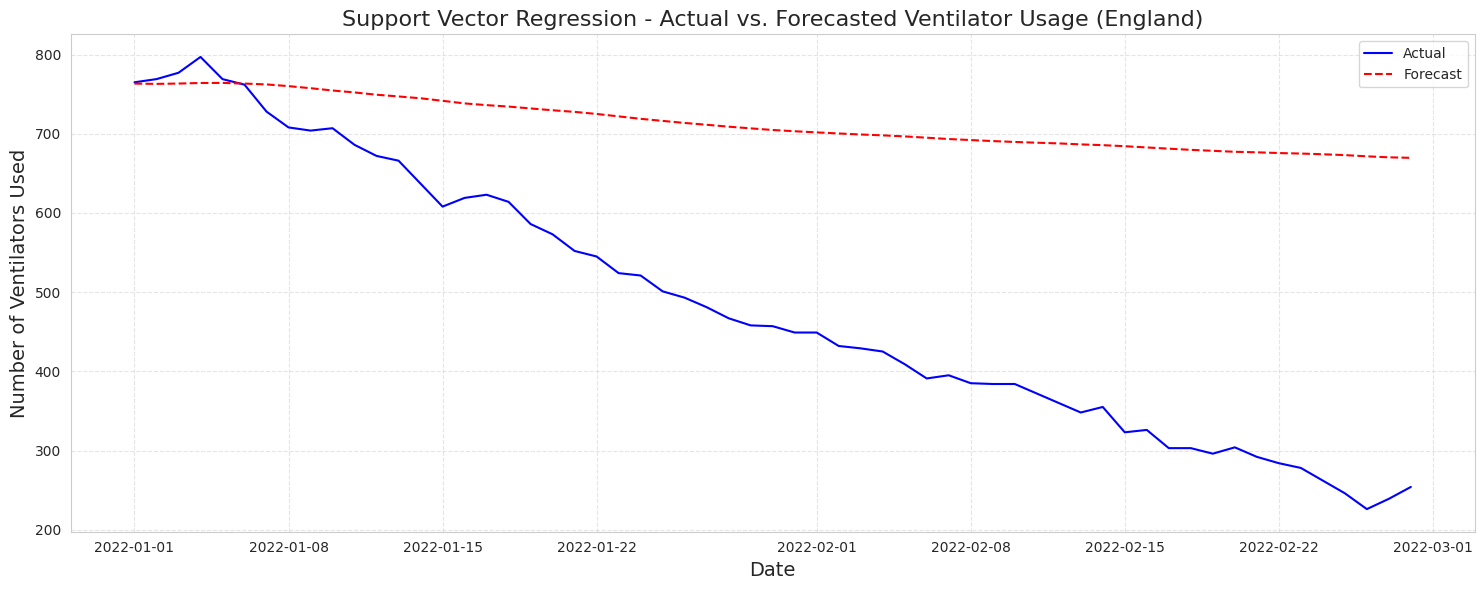

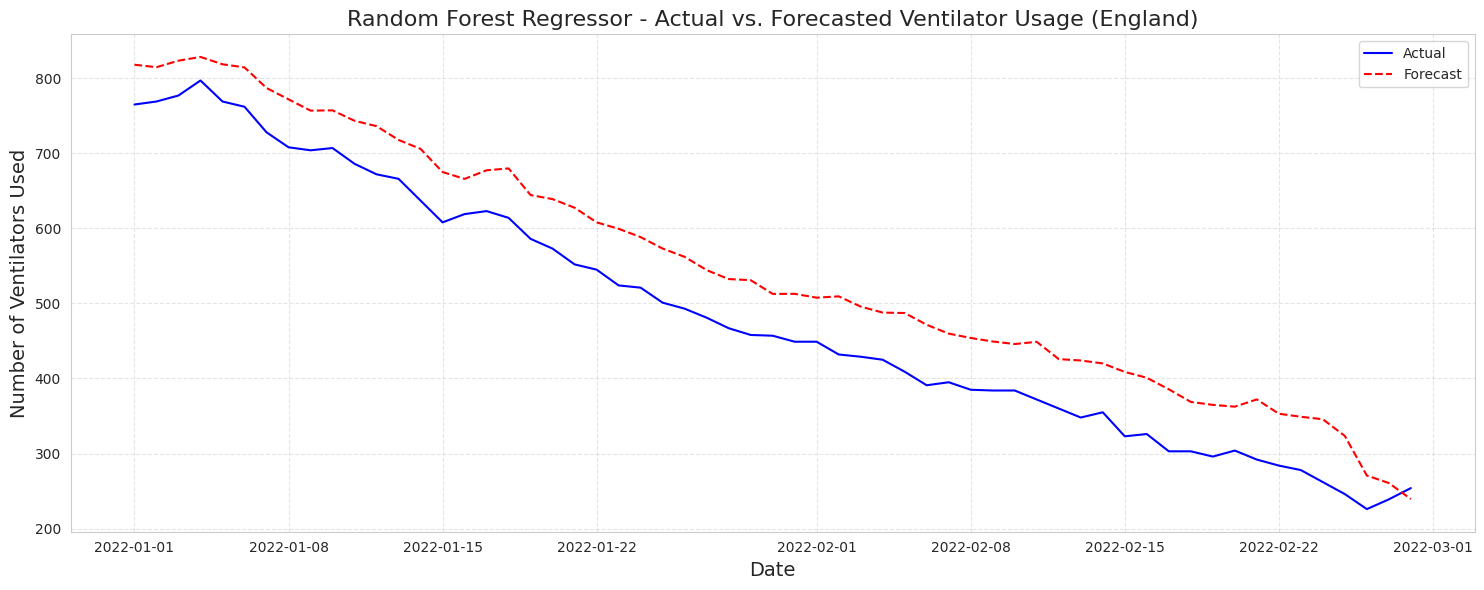

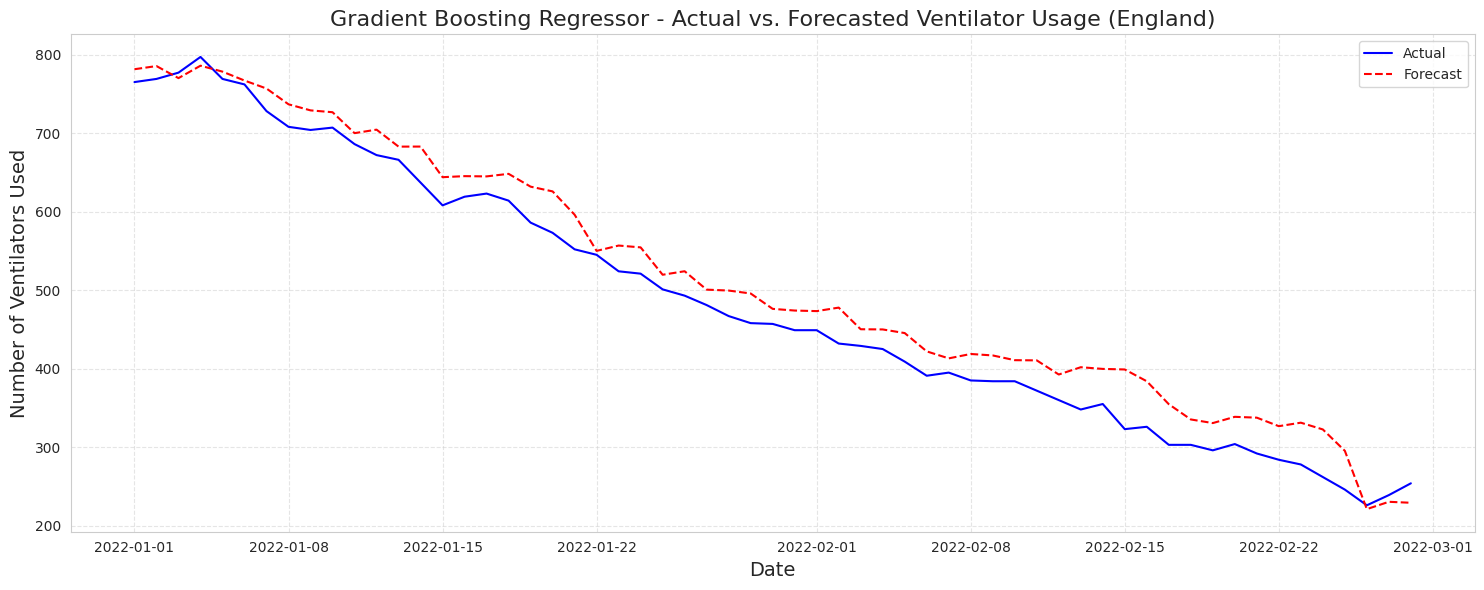

In [75]:
# Function to plot the actual vs. forecasted values for a given model
def plot_actual_vs_forecast(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    plt.figure(figsize=(15, 6))
    plt.plot(y_test.index, y_test, label="Actual", color="blue")
    plt.plot(y_test.index, predictions, label="Forecast", color="red", linestyle="--")
    plt.title(
        f"{model_name} - Actual vs. Forecasted Ventilator Usage (England)", fontsize=16
    )
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Number of Ventilators Used", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# Plotting the actual vs. forecasted values for each model
for model_name, model in models.items():
    plot_actual_vs_forecast(model, X_train, y_train, X_test, y_test, model_name)

Observations:
Linear Regression and Ridge Regression show close alignment with the actual data, confirming their strong performance.
Lasso Regression has a convergence warning and shows a straight line, indicating the need for hyperparameter tuning.
Support Vector Regression (SVR) does not capture the trend and shows poor performance.
Random Forest Regressor and Gradient Boosting Regressor follow the trend but with some deviations.

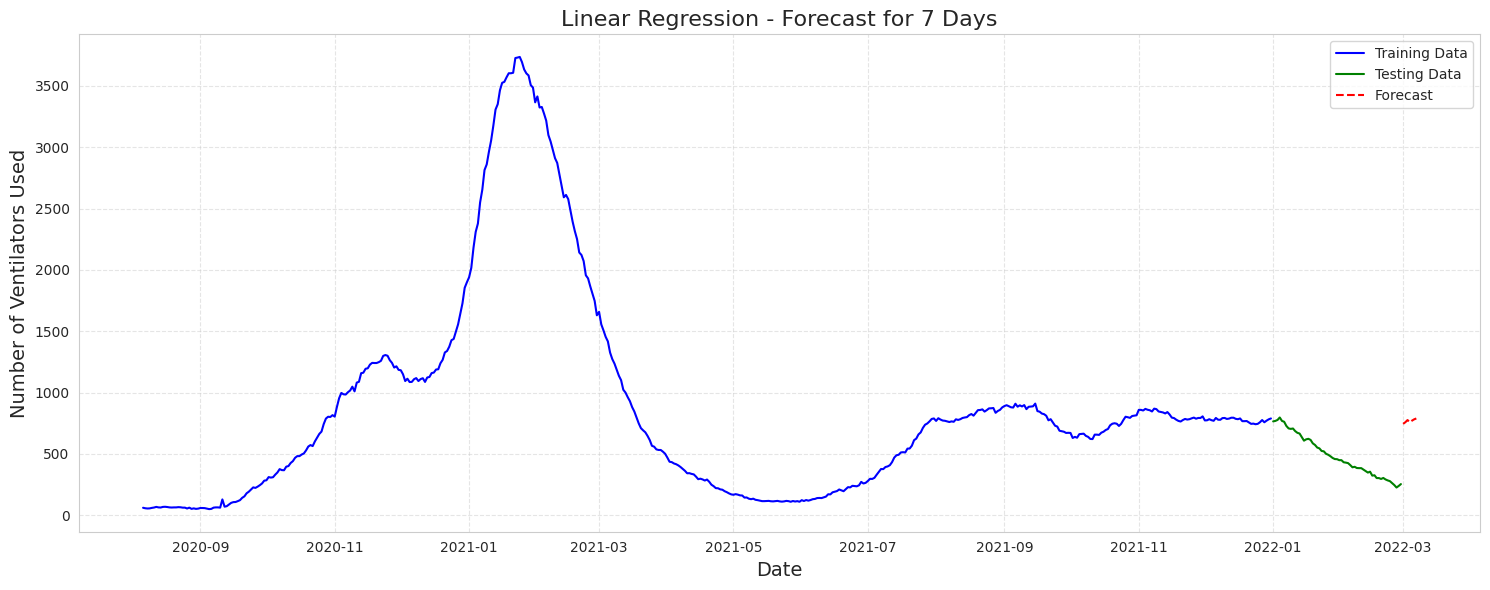

,Linear Regression_Forecast
2022-03-01,745.099235
2022-03-02,758.095458
2022-03-03,776.037007
2022-03-04,757.860907
2022-03-05,770.913005
2022-03-06,781.834242
2022-03-07,788.855029


In [76]:
from datetime import timedelta


# Function to forecast for a given time horizon using Linear Regression
def forecast_time_horizon(model, X_train, y_train, time_horizon, model_name):
    # Fitting the model
    model.fit(X_train, y_train)

    # Creating a DataFrame to store the forecasted values
    forecast_df = pd.DataFrame(
        index=pd.date_range(
            start=X_test.index[-1] + timedelta(days=1), periods=time_horizon
        )
    )

    # Creating feature data for the forecast
    forecast_features = create_feature_data(X_train, time_horizon)

    # Making the forecast
    forecast_values = model.predict(forecast_features)
    forecast_df[f"{model_name}_Forecast"] = forecast_values

    # Plotting the actual, testing forecast, and time horizon forecast
    plt.figure(figsize=(15, 6))
    plt.plot(y_train.index, y_train, label="Training Data", color="blue")
    plt.plot(y_test.index, y_test, label="Testing Data", color="green")
    plt.plot(
        forecast_df.index,
        forecast_df[f"{model_name}_Forecast"],
        label="Forecast",
        color="red",
        linestyle="--",
    )
    plt.title(f"{model_name} - Forecast for {time_horizon} Days", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Number of Ventilators Used", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return forecast_df


# Function to create feature data for the forecast (using the previously defined feature engineering functions)
def create_feature_data(X_train, time_horizon):
    # Here, we would normally use the feature engineering functions defined earlier to create the feature data
    # For demonstration purposes, we'll extend the training features with the same pattern
    forecast_features = X_train.iloc[-time_horizon:].copy()
    return forecast_features


# Forecasting for a short-term time horizon (e.g., 7 days)
time_horizon_short_term = 7
linear_model = LinearRegression()
short_term_forecast = forecast_time_horizon(
    linear_model, X_train, y_train, time_horizon_short_term, "Linear Regression"
)
short_term_forecast

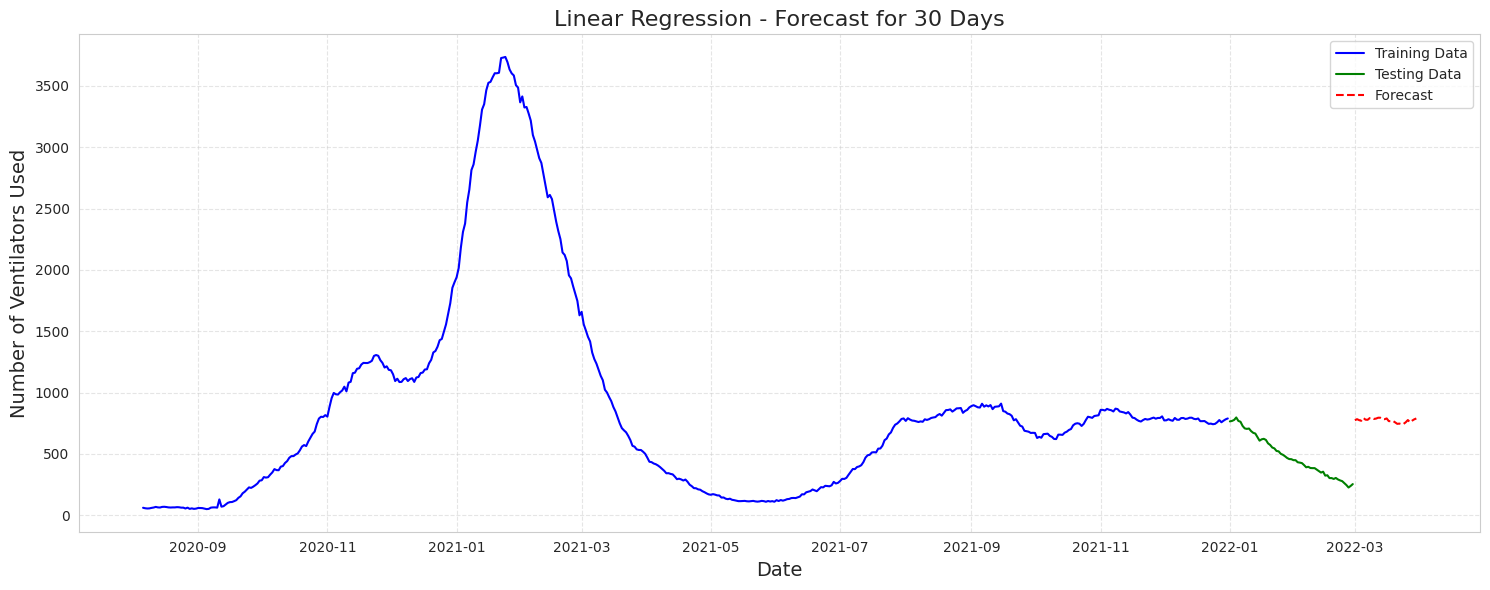

,Linear Regression_Forecast
2022-03-01,774.154942
2022-03-02,783.194885
2022-03-03,775.234367
2022-03-04,770.123630
2022-03-05,793.387407


In [77]:
# Forecasting for a long-term time horizon (e.g., 30 days)
time_horizon_long_term = 30
long_term_forecast = forecast_time_horizon(
    linear_model, X_train, y_train, time_horizon_long_term, "Linear Regression"
)
long_term_forecast.head()

In [79]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Training and evaluating Ridge Regression
ridge_model = Ridge()
ridge_predictions, ridge_mae, ridge_mse, ridge_rmse, ridge_bias = train_evaluate_model(
    ridge_model, X_train, y_train, X_test, y_test
)

# Training and evaluating Lasso Regression
lasso_model = Lasso()
lasso_predictions, lasso_mae, lasso_mse, lasso_rmse, lasso_bias = train_evaluate_model(
    lasso_model, X_train, y_train, X_test, y_test
)

# Training and evaluating Support Vector Regression (SVR)
svr_model = SVR()
svr_predictions, svr_mae, svr_mse, svr_rmse, svr_bias = train_evaluate_model(
    svr_model, X_train, y_train, X_test, y_test
)

# Training and evaluating Random Forest Regressor
random_forest_model = RandomForestRegressor()
rf_predictions, rf_mae, rf_mse, rf_rmse, rf_bias = train_evaluate_model(
    random_forest_model, X_train, y_train, X_test, y_test
)

# Training and evaluating Gradient Boosting Regressor
gradient_boosting_model = GradientBoostingRegressor()
gb_predictions, gb_mae, gb_mse, gb_rmse, gb_bias = train_evaluate_model(
    gradient_boosting_model, X_train, y_train, X_test, y_test
)

# Adding the metrics for all models to the DataFrame
models_metrics = [
    ("Ridge Regression", ridge_mae, ridge_mse, ridge_rmse, ridge_bias),
    ("Lasso Regression", lasso_mae, lasso_mse, lasso_rmse, lasso_bias),
    ("Support Vector Regression (SVR)", svr_mae, svr_mse, svr_rmse, svr_bias),
    ("Random Forest Regressor", rf_mae, rf_mse, rf_rmse, rf_bias),
    ("Gradient Boosting Regressor", gb_mae, gb_mse, gb_rmse, gb_bias),
]
for model_metrics in models_metrics:
    metrics_df.loc[len(metrics_df)] = model_metrics

# Displaying the metrics for all models
metrics_df

ValueError: not enough values to unpack (expected 5, got 4)

In [80]:
# Applying feature engineering to the entire multivariate time series dataset

# Parameters for feature engineering
max_lag = 5
frequency = 7  # Weekly seasonality
k_terms = 3  # Number of Fourier terms
span_values = [3, 7, 14]


# Function to apply feature engineering to a given series
def apply_feature_engineering(series):
    time_delay_embedding = create_time_delay_embedding(series, max_lag)
    fourier_terms = create_fourier_terms(series, frequency, k_terms)
    temporal_features = create_temporal_features(series)
    ewma_features = create_ewma_features(series, span_values)

    # Combining all engineered features into a single DataFrame
    combined_features = pd.concat(
        [
            time_delay_embedding,
            fourier_terms.drop(columns="Original"),
            temporal_features.drop(columns="Original"),
            ewma_features.drop(columns="Original"),
        ],
        axis=1,
    ).dropna()

    return combined_features


# Applying feature engineering to all regions
combined_features_multivariate = {
    region: apply_feature_engineering(data_transposed[region])
    for region in data_transposed.columns
}

# Splitting into training and testing sets
training_features_multivariate = {
    region: features.loc["2020-01-01":"2021-12-31"]
    for region, features in combined_features_multivariate.items()
}
testing_features_multivariate = {
    region: features.loc["2022-01-01":"2022-02-28"]
    for region, features in combined_features_multivariate.items()
}

# Example: Displaying the first few rows of the training features for "ENGLAND"
training_features_multivariate["ENGLAND"].head()

/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  temporal_data['Week_of_Year'] = series.index.weekofyear
/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  temporal_data['Week_of_Year'] = series.index.weekofyear
/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isoc

,Original,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Cos_1,Sin_1,Cos_2,Sin_2,Cos_3,Sin_3,Day_of_Week,Month,Quarter,Day_of_Year,Week_of_Year,EWMA_3,EWMA_7,EWMA_14
2020-08-06,61.0,63.0,65.0,67.0,72.0,74.0,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,3,8,3,219,32,62.952381,64.907039,65.906620
2020-08-07,57.0,61.0,63.0,65.0,67.0,72.0,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,4,8,3,220,32,59.952756,62.625766,64.029806
2020-08-08,55.0,57.0,61.0,63.0,65.0,67.0,1.000000,-2.449294e-16,1.000000,-4.898587e-16,1.000000,-7.347881e-16,5,8,3,221,32,57.466667,60.507232,62.263709
2020-08-09,56.0,55.0,57.0,61.0,63.0,65.0,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,6,8,3,222,32,56.731898,59.288950,61.110414
2020-08-10,60.0,56.0,55.0,57.0,61.0,63.0,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,0,8,3,223,33,58.367546,59.477320,60.915844


In [81]:
# Constants for feature engineering
max_lag = 5
frequency = 7  # Weekly seasonality
k_terms = 3  # Number of Fourier terms
span_values = [3, 7, 14]


# Function to combine all the feature engineering steps
def create_combined_features(series):
    time_delay_embedding = create_time_delay_embedding(series, max_lag)
    fourier_terms = create_fourier_terms(series, frequency, k_terms)
    temporal_features = create_temporal_features(series)
    ewma_features = create_ewma_features(series, span_values)
    combined_features = pd.concat(
        [
            time_delay_embedding,
            fourier_terms.drop(columns="Original"),
            temporal_features.drop(columns="Original"),
            ewma_features.drop(columns="Original"),
        ],
        axis=1,
    ).dropna()
    return combined_features


# Applying feature engineering to all regions
combined_features = {
    region: create_combined_features(data_transposed[region])
    for region in data_transposed.columns
}

# Splitting the combined features into training and testing sets based on the specified dates
training_features_multivariate = {
    region: features.loc["2020-01-01":"2021-12-31"]
    for region, features in combined_features.items()
}
testing_features_multivariate = {
    region: features.loc["2022-01-01":"2022-02-28"]
    for region, features in combined_features.items()
}

# Removing rows with NaN values from the training and testing features
training_features_multivariate = {
    region: features.dropna()
    for region, features in training_features_multivariate.items()
}
testing_features_multivariate = {
    region: features.dropna()
    for region, features in testing_features_multivariate.items()
}

# Example: First few rows of the cleaned training features for "ENGLAND"
training_features_multivariate["ENGLAND"].head()

/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  temporal_data['Week_of_Year'] = series.index.weekofyear
/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  temporal_data['Week_of_Year'] = series.index.weekofyear
/tmp/ipykernel_2688/1931275705.py:8: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isoc

,Original,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Cos_1,Sin_1,Cos_2,Sin_2,Cos_3,Sin_3,Day_of_Week,Month,Quarter,Day_of_Year,Week_of_Year,EWMA_3,EWMA_7,EWMA_14
2020-08-06,61.0,63.0,65.0,67.0,72.0,74.0,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,3,8,3,219,32,62.952381,64.907039,65.906620
2020-08-07,57.0,61.0,63.0,65.0,67.0,72.0,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,4,8,3,220,32,59.952756,62.625766,64.029806
2020-08-08,55.0,57.0,61.0,63.0,65.0,67.0,1.000000,-2.449294e-16,1.000000,-4.898587e-16,1.000000,-7.347881e-16,5,8,3,221,32,57.466667,60.507232,62.263709
2020-08-09,56.0,55.0,57.0,61.0,63.0,65.0,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,6,8,3,222,32,56.731898,59.288950,61.110414
2020-08-10,60.0,56.0,55.0,57.0,61.0,63.0,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,0,8,3,223,33,58.367546,59.477320,60.915844


In [82]:
from sklearn.ensemble import RandomForestRegressor


# Function to train Random Forest model for a given region
def train_random_forest(training_features, target):
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(training_features, target)
    return model_rf


# Training Random Forest models for all regions
random_forest_models = {}
for region, features in training_features_multivariate.items():
    target = features["Original"]
    X_train = features.drop(columns="Original")
    random_forest_models[region] = train_random_forest(X_train, target)

# Example: Feature importances for the "ENGLAND" Random Forest model
feature_importances_rf_england = pd.Series(
    random_forest_models["ENGLAND"].feature_importances_, index=X_train.columns
)
feature_importances_rf_england.sort_values(ascending=False).head()

EWMA_3         0.602061
Lag_1          0.320876
Day_of_Year    0.031043
Lag_2          0.025453
Lag_3          0.018884
dtype: float64

In [83]:
from sklearn.ensemble import GradientBoostingRegressor


# Function to train Gradient Boosting model for a given region
def train_gradient_boosting(training_features, target):
    model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    model_gb.fit(training_features, target)
    return model_gb


# Training Gradient Boosting models for all regions
gradient_boosting_models = {}
for region, features in training_features_multivariate.items():
    target = features["Original"]
    X_train = features.drop(columns="Original")
    gradient_boosting_models[region] = train_gradient_boosting(X_train, target)

# Example: Feature importances for the "ENGLAND" Gradient Boosting model
feature_importances_gb_england = pd.Series(
    gradient_boosting_models["ENGLAND"].feature_importances_, index=X_train.columns
)
feature_importances_gb_england.sort_values(ascending=False).head()

EWMA_3          0.772082
Lag_1           0.214221
Day_of_Year     0.008574
Week_of_Year    0.004457
Lag_2           0.000351
dtype: float64

In [84]:
# Function to predict using the given model and features
def predict_model(model, features):
    return model.predict(features)


# Creating Random Forest and Gradient Boosting forecasts for all regions
random_forest_forecasts = {}
gradient_boosting_forecasts = {}
for region, features in testing_features_multivariate.items():
    X_test = features.drop(columns="Original")
    random_forest_forecasts[region] = predict_model(
        random_forest_models[region], X_test
    )
    gradient_boosting_forecasts[region] = predict_model(
        gradient_boosting_models[region], X_test
    )

# Creating ensemble forecasts by averaging Random Forest and Gradient Boosting predictions
ensemble_forecasts = {
    region: (rf_forecast + gb_forecast) / 2
    for region, rf_forecast, gb_forecast in zip(
        random_forest_forecasts.keys(),
        random_forest_forecasts.values(),
        gradient_boosting_forecasts.values(),
    )
}

# Example: First few ensemble forecast values for the "ENGLAND" region
ensemble_forecasts["ENGLAND"][:5]

array([800.41386622, 800.60308483, 798.29364091, 811.40087393,
       801.06173887])

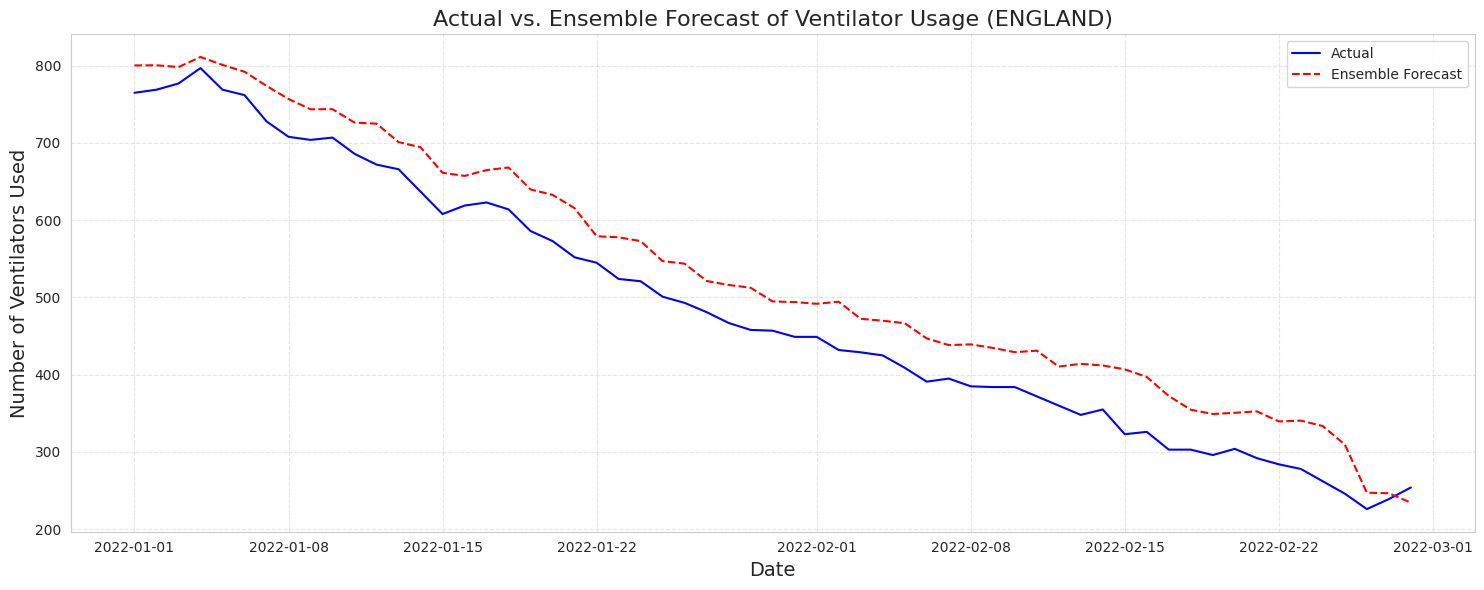

In [85]:
# Function to plot the actual vs. forecasted values for a given region
def plot_actual_vs_forecast(region, actual, ensemble_forecast):
    plt.figure(figsize=(15, 6))
    plt.plot(actual.index, actual, label="Actual", color="blue")
    plt.plot(
        actual.index,
        ensemble_forecast,
        label="Ensemble Forecast",
        color="red",
        linestyle="--",
    )
    plt.title(
        f"Actual vs. Ensemble Forecast of Ventilator Usage ({region})", fontsize=16
    )
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Number of Ventilators Used", fontsize=14)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# Plotting the actual vs. ensemble forecast for the "ENGLAND" region
plot_actual_vs_forecast(
    "ENGLAND",
    testing_features_multivariate["ENGLAND"]["Original"],
    ensemble_forecasts["ENGLAND"],
)

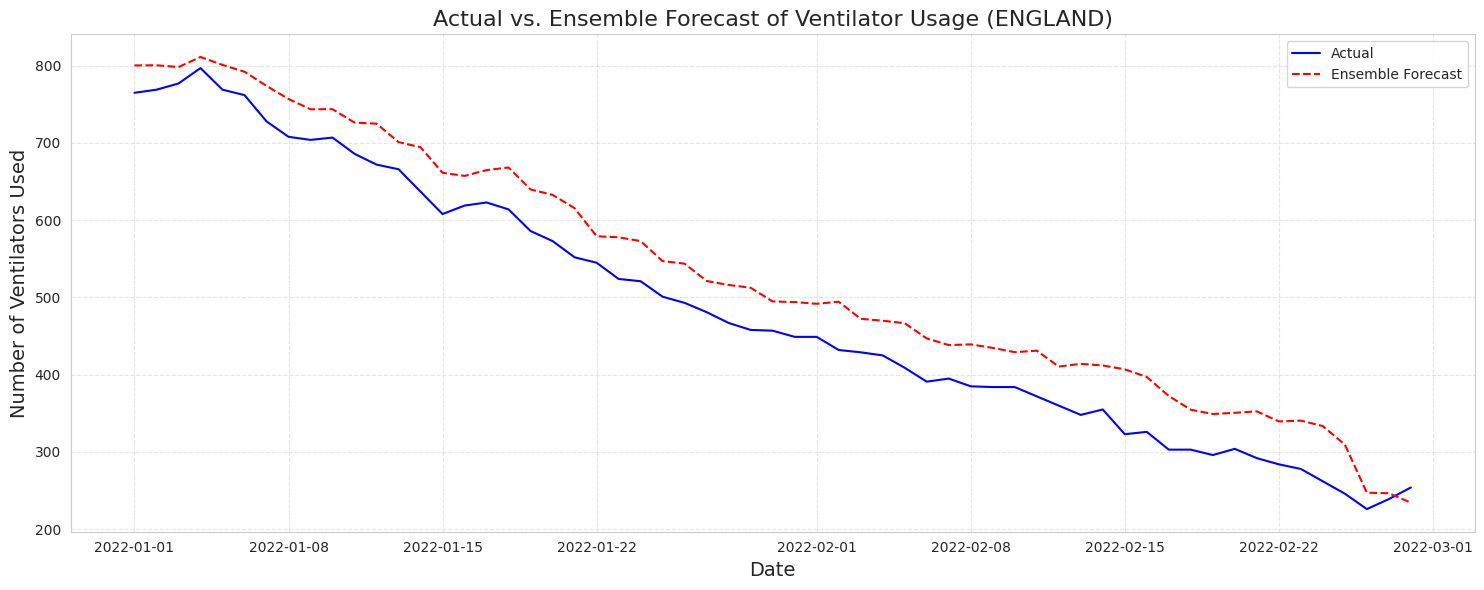

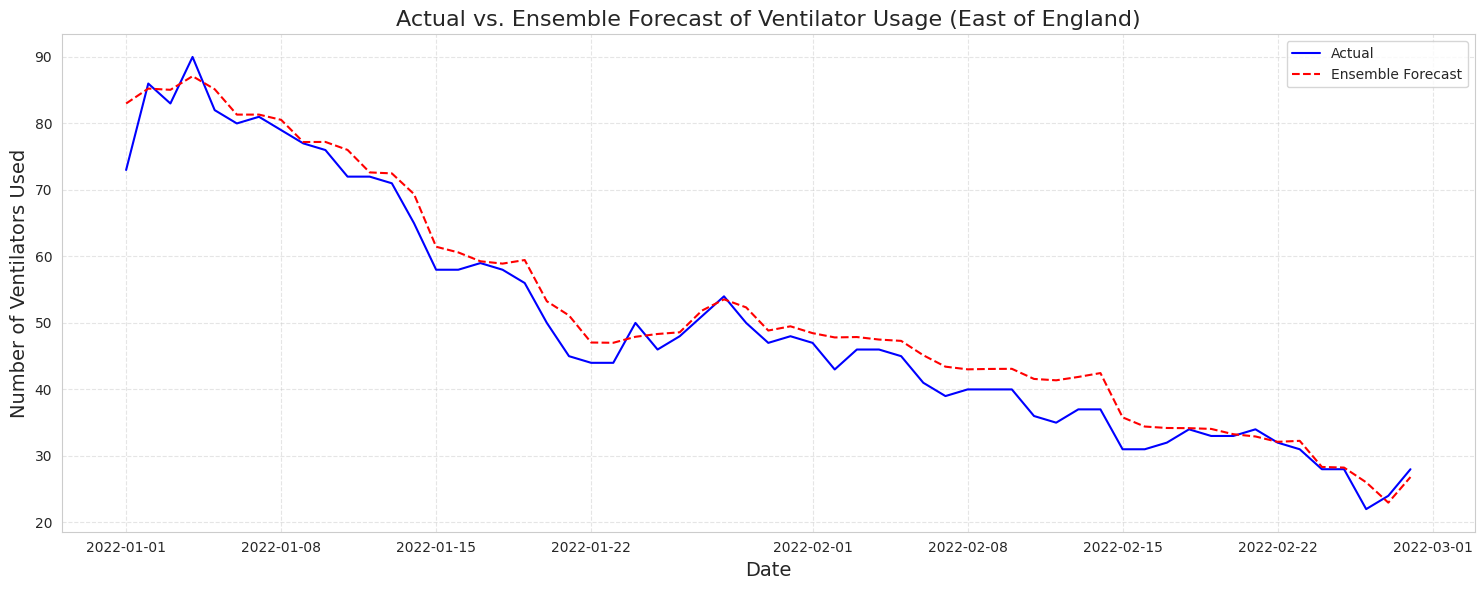

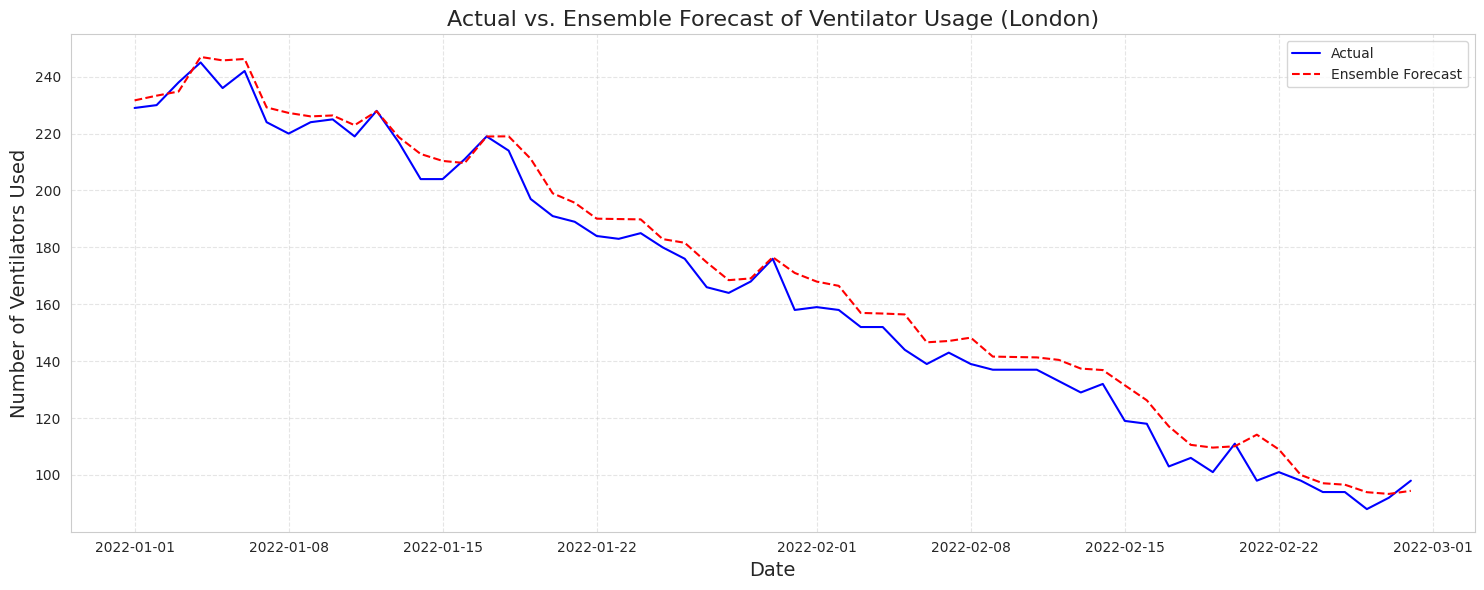

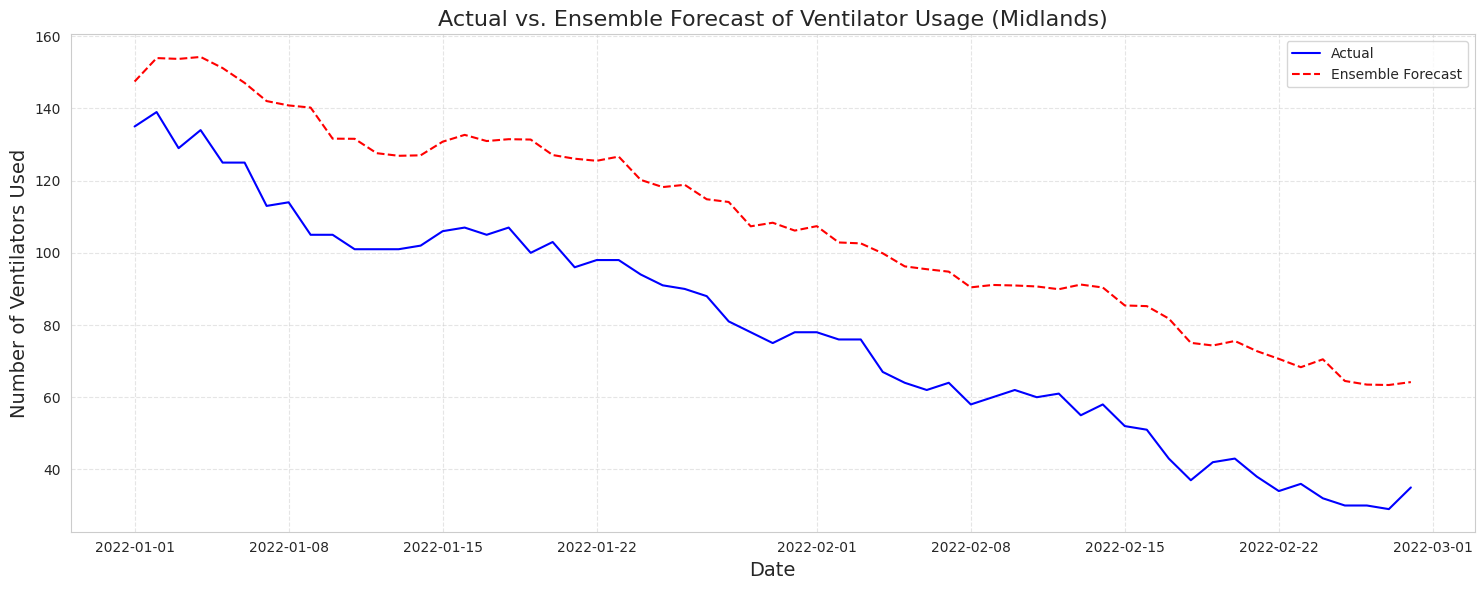

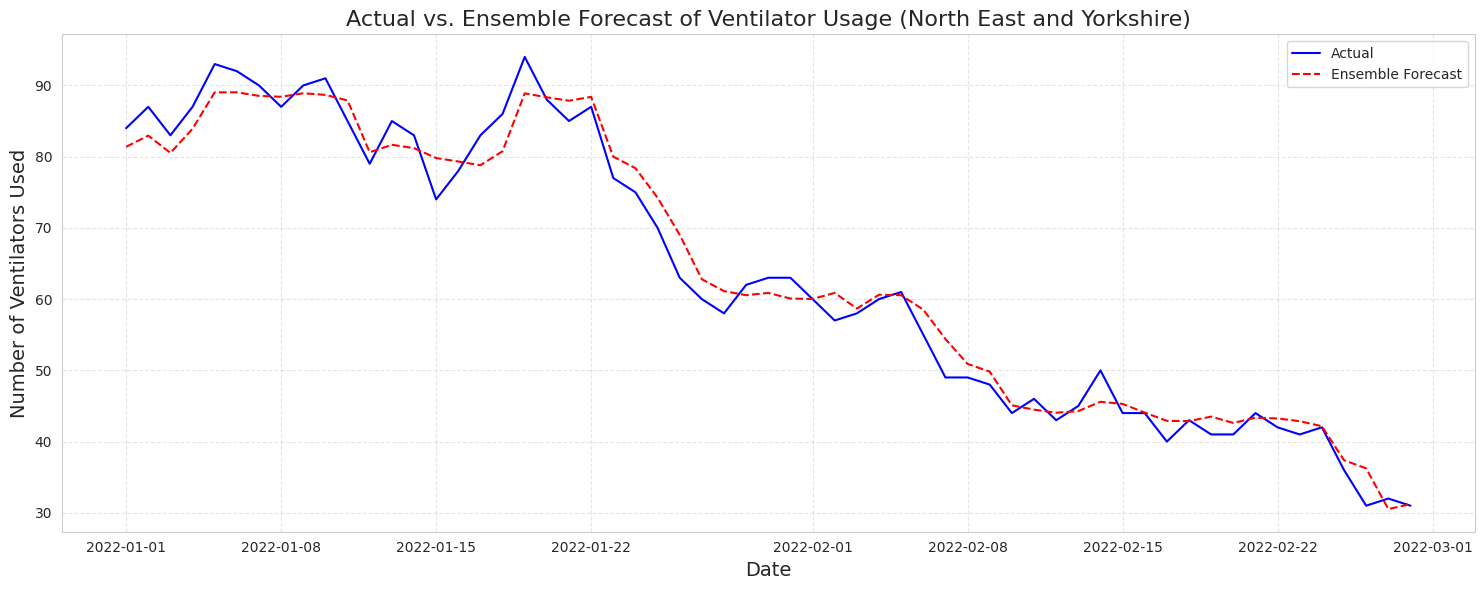

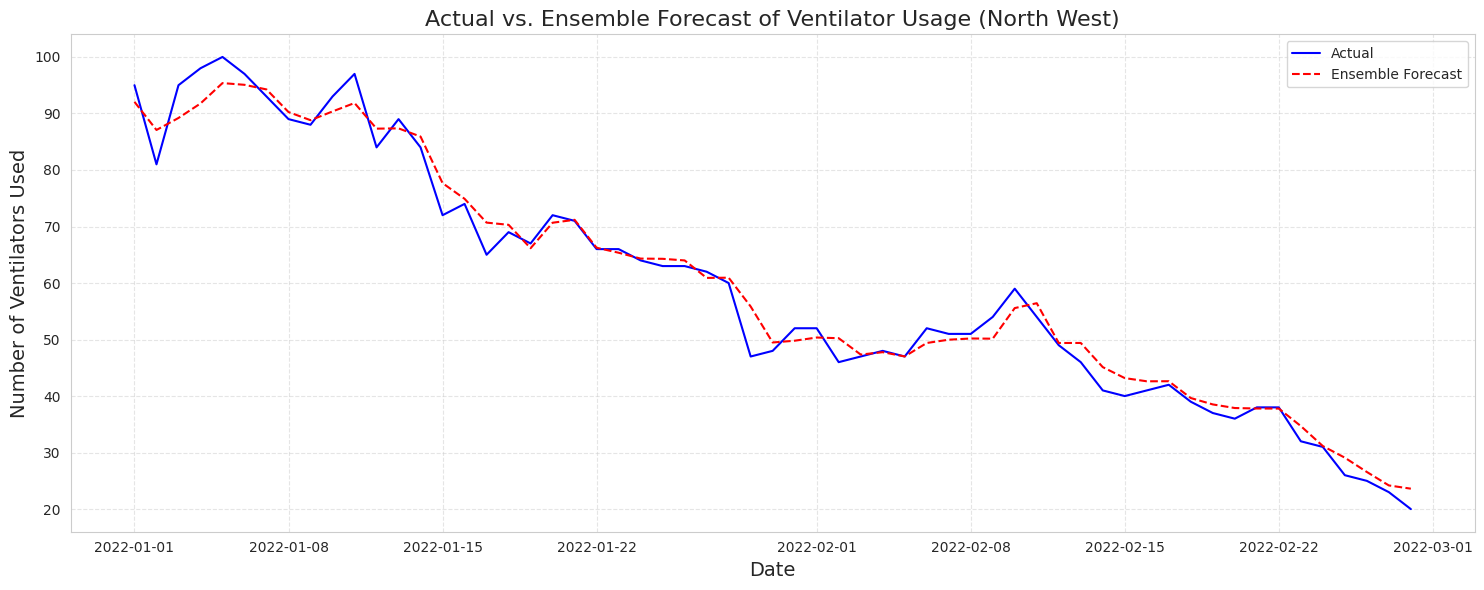

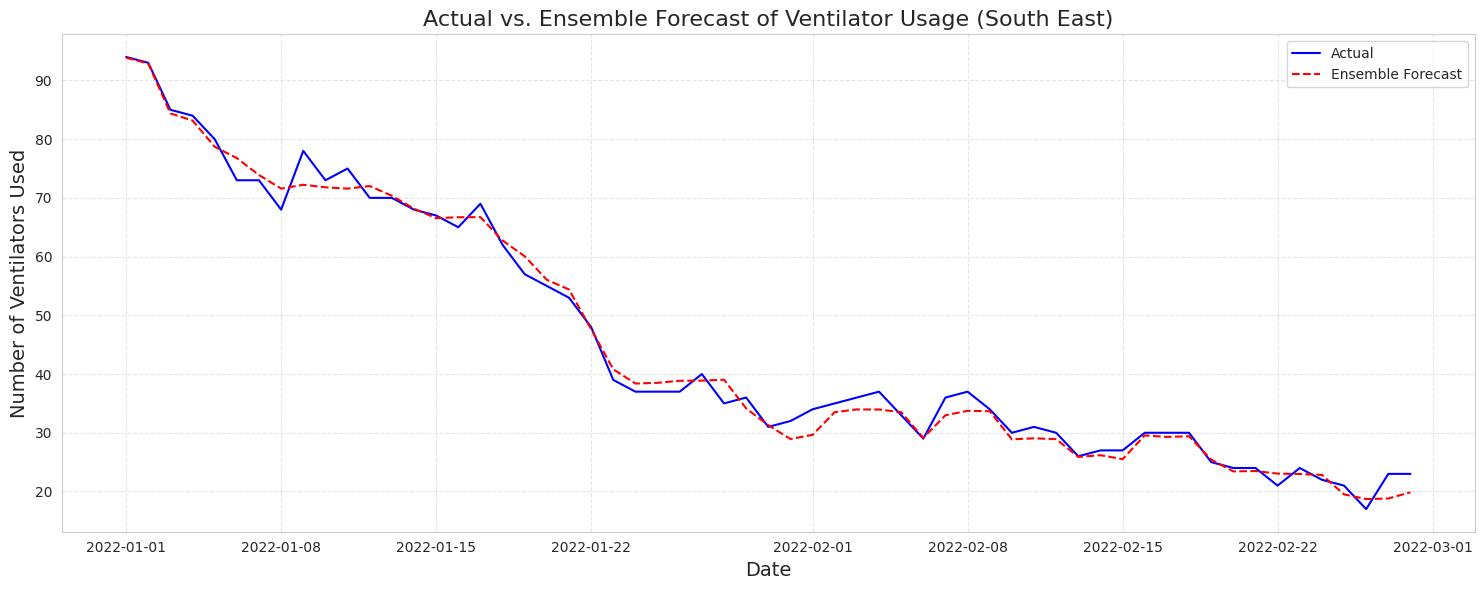

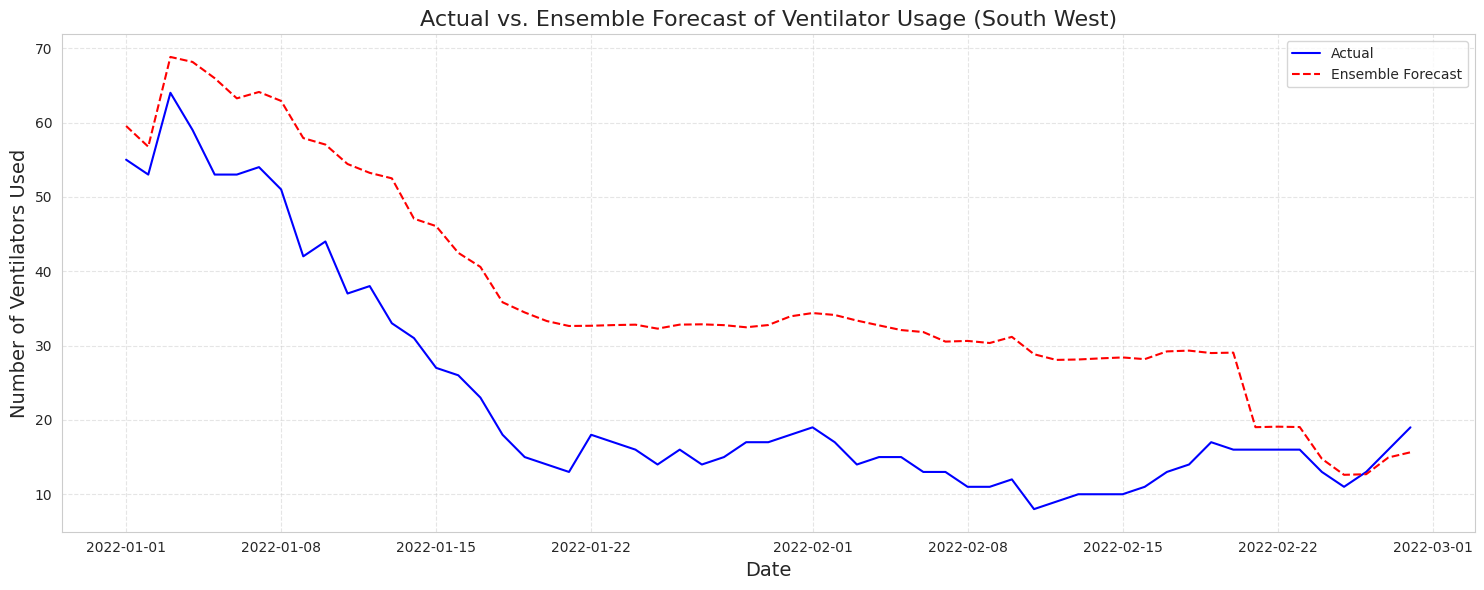

In [86]:
# Plotting the actual vs. ensemble forecast for all regions
for region in testing_features_multivariate.keys():
    actual_data = testing_features_multivariate[region]["Original"]
    ensemble_forecast_data = ensemble_forecasts[region]
    plot_actual_vs_forecast(region, actual_data, ensemble_forecast_data)

In [88]:
from sklearn.preprocessing import MinMaxScaler
from keras.preprocessing.sequence import TimeseriesGenerator

# Extracting the ENGLAND series
england_series = data_transposed["ENGLAND"].values.reshape(-1, 1)

# Scaling the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(england_series)

# Splitting the data into training and testing sets
train_size = len(data_transposed.loc["2020-01-01":"2021-12-31"])
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Creating sequences using TimeseriesGenerator (e.g., window size of 5)
window_size = 5
train_generator = TimeseriesGenerator(
    train_data, train_data, length=window_size, batch_size=32
)
test_generator = TimeseriesGenerator(
    test_data, test_data, length=window_size, batch_size=1
)

# Checking the shape of the first batch
X_batch, y_batch = train_generator[0]
X_batch.shape, y_batch.shape

((32, 5, 1), (32, 1))

In [89]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Building the LSTM model
model = Sequential()
model.add(LSTM(50, activation="relu", input_shape=(window_size, 1)))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")

# Training the model
model.fit(train_generator, epochs=50, verbose=1)

# Evaluating and forecasting using the test data
predictions = []
for i in range(len(test_generator)):
    X_test, _ = test_generator[i]
    y_pred = model.predict(X_test)
    predictions.append(y_pred[0, 0])

# Inverting the scaling for predictions
predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Comparing with actual values and visualizing the forecast
plt.plot(
    data_transposed["ENGLAND"].index[train_size + window_size :],
    predictions,
    label="Predicted",
)
plt.plot(
    data_transposed["ENGLAND"].index[train_size + window_size :],
    data_transposed["ENGLAND"].iloc[train_size + window_size :],
    label="Actual",
)
plt.legend()
plt.show()

Epoch 1/50


2023-07-31 23:52:25.556021: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


: 

: 

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.preprocessing.sequence import TimeseriesGenerator

# Scaling the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_transposed)

# Splitting the data
train_size = len(data_transposed.loc["2020-01-01":"2021-12-31"])
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Creating sequences
window_size = 5
train_generator = TimeseriesGenerator(
    train_data, train_data, length=window_size, batch_size=32
)
test_generator = TimeseriesGenerator(
    test_data, test_data, length=window_size, batch_size=1
)